# Pearson Feature-Selection Grid for ECH Combined Strategy Candidates



This notebook explores the Pearson-correlation version of the ML predictor before building a combined strategy. It mirrors the broad workflow of `test_PCA_scaler_comparison.ipynb`: configure a compact grid, run the grid in parallel, collect artifacts, build leaderboards, and inspect feature-selection diagnostics.


## First search: testing many parameter sets for year `2025` to determine top 10 and then run combined strategy.


The first candidate search is the **combined strategy for top performers in 2025**. A second candidate search is duplicated below for the longer 2023-2025 window, so we can later test top combined strategy candidates on 2026-YTD data.

### Experiment Design


The predictor is run through `run_single_case_features_Sharpe.py`, which uses the Pearson feature selector in `ML_predictor_features_Sharpe.py`. The first grid keeps the same trading assumptions used in the PCA scaler comparison: `training_years=10`, `start_date="2025-01-01"`, `end_date="2026-01-01"`, and `sharpe_filter_enabled=False`.

The `n_features` grid spans 1 to 20 in steps of 1. The `signal_threshold` grid spans 0 to 0.01 with denser low-threshold steps, because costs argue against always trading tiny predicted edges, while predictor accuracy argues against setting the threshold so high that the model almost never trades.

All grid searches use 15 parallel workers via joblib's `loky` backend.

In [1]:
from pathlib import Path
import itertools
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"

for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import run_single_case_features_Sharpe as pearson_runner_module
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")


Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


In [2]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

N_FEATURES_GRID = list(range(1, 21))
SIGNAL_THRESHOLD_GRID = [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01]

COMMON_PARAMS_2025 = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": 10,
    "sharpe_filter_enabled": False,
    "feature_diagnostics_enabled": True,
    # None records all ranked Pearson feature scores available after the variance filter.
    # Set to an integer such as 30 if the diagnostics become too large.
    "feature_diagnostics_top_n": None,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

COMMON_PARAMS_2023_2025 = {
    **COMMON_PARAMS_2025,
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
}

# Keep this alias for cells that operate on the first candidate search by default.
COMMON_PARAMS = COMMON_PARAMS_2025

RUN_GRID = True
N_JOBS = 15
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_ROOT = ml_dir / "test_Pearson_combined_strategy_outputs"
OUTPUT_DIR_2025 = OUTPUT_ROOT / "combined_strategy_top_performers_2025"
OUTPUT_DIR_2023_2025 = OUTPUT_ROOT / "test_top_combined_strategy_2023_2025_for_2026_ytd"
for output_dir in [OUTPUT_DIR_2025, OUTPUT_DIR_2023_2025]:
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"2025 output directory: {OUTPUT_DIR_2025}")
print(f"2023-2025 output directory: {OUTPUT_DIR_2023_2025}")

2025 output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_Pearson_combined_strategy_outputs/combined_strategy_top_performers_2025
2023-2025 output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_Pearson_combined_strategy_outputs/test_top_combined_strategy_2023_2025_for_2026_ytd


### Metric Helpers


These helpers compute the same family of performance and behavior metrics used in the PCA comparison notebook: returns, drawdown, Sharpe, adjusted Sortino, activity/exposure, turnover, fees, and prediction distribution.

`adjusted_net_sortino` is divided by `sqrt(2)` so it is more directly comparable with Sharpe, matching the adjustment used in the backtester tearsheet.

Return win/loss/zero rates are calculated from gross returns, not net returns. This avoids counting an otherwise-flat trading day as a losing day just because transaction costs were applied.

In [3]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, n_features: int, signal_threshold) -> str:
    return f"{symbol}_features-{n_features}_sig-{safe_value(signal_threshold)}"


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    vol = returns.std()
    if vol == 0 or np.isnan(vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside = returns[returns < 0]
    downside_vol = downside.std()
    if downside_vol == 0 or np.isnan(downside_vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_vol


def adjusted_annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    sortino_value = annualized_sortino(returns, periods_per_year=periods_per_year)
    if pd.isna(sortino_value):
        return np.nan
    return sortino_value / np.sqrt(2)


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    grid_index: int,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    strategy,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100

    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)

    prediction_counts = pd.Series(dtype=float)
    if strategy.weight_diagnostics_ is not None and "prediction" in strategy.weight_diagnostics_.columns:
        prediction_counts = strategy.weight_diagnostics_["prediction"].value_counts(normalize=True).sort_index() * 100

    return {
        "grid_index": grid_index,
        "run_id": run_id,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "start_date": params["start_date"],
        "end_date": params["end_date"],
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "adjusted_net_sortino": adjusted_annualized_sortino(stats["net_returns"]),
        "gross_win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "gross_loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "gross_zero_return_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
    }

### Pearson Feature Diagnostics



The Pearson predictor records the ranked absolute Pearson-correlation score for each feature on each prediction date. The summary below helps identify which features are repeatedly selected, which are merely highly ranked, and whether a candidate run depends on a narrow or broad set of indicators.

In [4]:
def feature_summary_from_diagnostics(diagnostics: pd.DataFrame) -> pd.DataFrame:
    if diagnostics is None or diagnostics.empty:
        return pd.DataFrame()

    grouped = diagnostics.groupby("feature")
    summary = grouped.agg(
        appearances=("feature", "size"),
        selected_appearances=("selected", "sum"),
        mean_abs_corr=("pearson_abs_corr", "mean"),
        median_abs_corr=("pearson_abs_corr", "median"),
        mean_rank=("rank", "mean"),
        best_rank=("rank", "min"),
    )
    summary["selection_rate_pct"] = summary["selected_appearances"] / summary["appearances"] * 100
    return summary.sort_values(
        ["selected_appearances", "mean_abs_corr"],
        ascending=[False, False],
    )


def selected_feature_counts(diagnostics: pd.DataFrame, top_n: int = 30) -> pd.Series:
    if diagnostics is None or diagnostics.empty:
        return pd.Series(dtype=float)
    selected = diagnostics[diagnostics["selected"]]
    return selected["feature"].value_counts().head(top_n)


def plot_selected_feature_frequency(feature_summary: pd.DataFrame, top_n: int = 30, title: str = "Selected Feature Frequency"):
    if feature_summary.empty:
        print("No feature summary available.")
        return None

    top = feature_summary.sort_values("selected_appearances", ascending=False).head(top_n)
    ax = top["selected_appearances"].sort_values().plot(kind="barh", figsize=(10, max(4, 0.3 * len(top))))
    ax.set_title(title)
    ax.set_xlabel("Selected appearances")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    return ax

### Runner Wrapper



`run_single_case_features_Sharpe.py` currently always creates a tearsheet and does not return the backtest artifacts. To keep this notebook self-contained without editing that script, the helper below temporarily wraps the runner's `PortfolioVectorEngine` reference, captures the generated stats/weights/prices, and suppresses tearsheet generation during grid search.

In [5]:
def run_single_case_features_capture(
    *,
    symbol: str,
    asset_class: str,
    start_date: str,
    end_date: str,
    signal_threshold: float,
    n_features: int,
    training_years: int,
    sharpe_filter_enabled: bool,
    feature_diagnostics_enabled: bool,
    feature_diagnostics_top_n,
    position_size: float,
    initial_capital: float,
    max_iter: int,
    execution_delay: int,
    verbose: bool,
    show_progress: bool,
    show_tearsheet: bool = False,
) -> dict:
    captured = {}
    original_engine_class = pearson_runner_module.PortfolioVectorEngine

    class CapturingPortfolioVectorEngine(original_engine_class):
        def run(self):
            stats = super().run()
            captured["prices"] = self.prices.copy()
            captured["weights"] = self.signals.copy()
            captured["stats"] = stats.copy()
            return stats

        def tearsheet(self, title="Multi-Asset Alpha Discovery Tearsheet"):
            if show_tearsheet:
                return super().tearsheet(title)
            return None

    pearson_runner_module.PortfolioVectorEngine = CapturingPortfolioVectorEngine
    try:
        strategy = pearson_runner_module.run_single_case_features_Sharpe(
            symbol=symbol,
            asset_class=asset_class,
            start_date=start_date,
            end_date=end_date,
            signal_threshold=signal_threshold,
            n_features=n_features,
            training_years=training_years,
            sharpe_filter_enabled=sharpe_filter_enabled,
            feature_diagnostics_enabled=feature_diagnostics_enabled,
            feature_diagnostics_top_n=feature_diagnostics_top_n,
            position_size=position_size,
            initial_capital=initial_capital,
            max_iter=max_iter,
            execution_delay=execution_delay,
            verbose=verbose,
            show_progress=show_progress,
            return_strategy=True,
        )
    finally:
        pearson_runner_module.PortfolioVectorEngine = original_engine_class

    if "stats" not in captured:
        raise ValueError("No backtest stats were captured. The runner may have produced empty weights.")

    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "training_years": training_years,
        "sharpe_filter_enabled": sharpe_filter_enabled,
        "feature_diagnostics_enabled": feature_diagnostics_enabled,
        "feature_diagnostics_top_n": feature_diagnostics_top_n,
        "position_size": position_size,
        "max_iter": max_iter,
        "verbose": verbose,
    }

    return {
        "params": params,
        "strategy": strategy,
        "prices": captured["prices"],
        "weights": captured["weights"],
        "stats": captured["stats"],
    }

### Case Runner



This function runs one Pearson grid case, computes performance metrics, extracts feature diagnostics, and optionally saves artifacts to disk. The grid worker uses this function through a safe wrapper so failures are collected instead of stopping the whole grid.

In [16]:
def save_case_artifacts(run_id: str, artifacts: dict, output_dir: Path) -> None:
    run_dir = output_dir / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["prices"].to_pickle(run_dir / "prices.pkl")
    artifacts["feature_diagnostics"].to_pickle(run_dir / "feature_diagnostics.pkl")
    artifacts["feature_summary"].to_pickle(run_dir / "feature_summary.pkl")
    artifacts["weight_diagnostics"].to_pickle(run_dir / "weight_diagnostics.pkl")

    with open(run_dir / "metrics.json", "w") as f:
        json.dump(artifacts["metrics"], f, indent=2, default=str)


def run_one_case(grid_index: int, n_features: int, signal_threshold: float, common_params: dict, output_dir: Path) -> dict:
    symbol = common_params["symbol"]
    run_id = make_run_id(symbol, n_features, signal_threshold)
    print(f"Running grid_index={grid_index}: {run_id}")
    start = time.time()

    runner_artifacts = run_single_case_features_capture(
        symbol=symbol,
        asset_class=ASSET_CLASS,
        start_date=common_params["start_date"],
        end_date=common_params["end_date"],
        signal_threshold=signal_threshold,
        n_features=n_features,
        training_years=common_params["training_years"],
        sharpe_filter_enabled=common_params["sharpe_filter_enabled"],
        feature_diagnostics_enabled=common_params["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=common_params["feature_diagnostics_top_n"],
        position_size=common_params["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=common_params["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=common_params["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    strategy = runner_artifacts["strategy"]
    weights = runner_artifacts["weights"]
    stats = runner_artifacts["stats"]

    feature_diagnostics = strategy.feature_selection_diagnostics_.copy()
    feature_summary = feature_summary_from_diagnostics(feature_diagnostics)
    weight_diagnostics = strategy.weight_diagnostics_.copy() if strategy.weight_diagnostics_ is not None else pd.DataFrame()

    metrics = summarize_performance(run_id, grid_index, runner_artifacts["params"], stats, weights, strategy)
    metrics.update({
        "elapsed_seconds": time.time() - start,
        "diagnostic_rows": len(feature_diagnostics),
        "unique_diagnostic_features": feature_diagnostics["feature"].nunique() if not feature_diagnostics.empty else 0,
        "unique_selected_features": feature_diagnostics.loc[feature_diagnostics["selected"], "feature"].nunique() if not feature_diagnostics.empty else 0,
        "mean_selected_abs_corr": feature_diagnostics.loc[feature_diagnostics["selected"], "pearson_abs_corr"].mean() if not feature_diagnostics.empty else np.nan,
    })

    artifacts = {
        **runner_artifacts,
        "run_id": run_id,
        "grid_index": grid_index,
        "feature_diagnostics": feature_diagnostics,
        "feature_summary": feature_summary,
        "weight_diagnostics": weight_diagnostics,
        "metrics": metrics,
    }

    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts, output_dir)

    return artifacts


def run_one_case_safely(indexed_case, common_params: dict, output_dir: Path):
    grid_index, (n_features, signal_threshold) = indexed_case
    run_id = make_run_id(common_params["symbol"], n_features, signal_threshold)
    try:
        artifacts = run_one_case(grid_index, n_features, signal_threshold, common_params, output_dir)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "grid_index": grid_index,
            "run_id": run_id,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


def run_grid_search(common_params: dict, output_dir: Path):
    grid_artifacts = {}
    grid_metrics = []
    grid_errors = []

    grid_cases = list(enumerate(itertools.product(N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID)))
    print(f"Total cases: {len(grid_cases)}")

    if RUN_GRID:
        grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
            delayed(run_one_case_safely)(case, common_params, output_dir)
            for case in grid_cases
        )

        for result in grid_results:
            if result["ok"]:
                grid_artifacts[result["run_id"]] = result["artifacts"]
                grid_metrics.append(result["artifacts"]["metrics"])
            else:
                grid_errors.append({key: value for key, value in result.items() if key != "ok"})

    metrics_df = pd.DataFrame(grid_metrics)
    if not metrics_df.empty:
        metrics_df = metrics_df.set_index("grid_index").sort_index()
        metrics_df.index.name = "grid_index"

    errors_df = pd.DataFrame(grid_errors)
    if not errors_df.empty and "grid_index" in errors_df.columns:
        errors_df = errors_df.set_index("grid_index").sort_index()
        errors_df.index.name = "grid_index"

    if SAVE_ARTIFACTS and not metrics_df.empty:
        metrics_df.to_pickle(output_dir / "grid_metrics.pkl")
        metrics_df.to_csv(output_dir / "grid_metrics.csv")
    if SAVE_ARTIFACTS and not errors_df.empty:
        errors_df.to_csv(output_dir / "grid_errors.csv")

    return metrics_df, errors_df, grid_artifacts


def leaderboard_columns(metrics_df: pd.DataFrame):
    cols = [
        "run_id", "n_features", "signal_threshold",
        "net_sharpe", "adjusted_net_sortino", "net_return_pct", "gross_return_pct",
        "excess_vs_benchmark_pct", "max_drawdown_pct", "total_fees_paid",
        "active_days_pct", "average_abs_exposure", "average_daily_turnover",
        "gross_win_rate_pct", "gross_loss_rate_pct", "gross_zero_return_rate_pct",
        "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
        "diagnostic_rows", "unique_selected_features", "mean_selected_abs_corr",
    ]
    return [col for col in cols if col in metrics_df.columns]


def show_leaderboards(metrics_df: pd.DataFrame, errors_df: pd.DataFrame, title: str, top_n: int = 15):
    cols = leaderboard_columns(metrics_df)
    print(title)
    print("Top by net Sharpe")
    display(metrics_df[cols].sort_values("net_sharpe", ascending=False).head(top_n).round(2))

    print("Top by net return")
    display(metrics_df[cols].sort_values("net_return_pct", ascending=False).head(top_n).round(2))

    print("Best drawdown control")
    print("Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.")
    drawdown_candidates = metrics_df[metrics_df["active_days_pct"] >= 1.0]
    display(drawdown_candidates[cols].sort_values("max_drawdown_pct", ascending=False).head(top_n).round(2))

    display(errors_df)

### Parallel Grid Search


The grid below uses `Parallel(n_jobs=15, backend="loky", verbose=...)`. The DataFrame index is the grid index. If we refer to a run number in discussion, we mean this grid index.

In [7]:
metrics_df, errors_df, grid_artifacts = run_grid_search(COMMON_PARAMS_2025, OUTPUT_DIR_2025)
show_leaderboards(
    metrics_df,
    errors_df,
    title="Combined strategy candidates for top performers in 2025",
)

Total cases: 160


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


Running grid_index=0: ECH_features-1_sig-0
Running grid_index=1: ECH_features-1_sig-0p001
Running grid_index=2: ECH_features-1_sig-0p002
Running grid_index=6: ECH_features-1_sig-0p0075
Running grid_index=3: ECH_features-1_sig-0p003
Running grid_index=4: ECH_features-1_sig-0p004
Running grid_index=5: ECH_features-1_sig-0p005
Running grid_index=14: ECH_features-2_sig-0p0075
Running grid_index=7: ECH_features-1_sig-0p01
Running grid_index=10: ECH_features-2_sig-0p002
Running grid_index=9: ECH_features-2_sig-0p001
Running grid_index=12: ECH_features-2_sig-0p004
Running grid_index=11: ECH_features-2_sig-0p003
Running grid_index=8: ECH_features-2_sig-0
Running grid_index=13: ECH_features-2_sig-0p005
Running grid_index=15: ECH_features-2_sig-0p01


[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:   38.0s


Running grid_index=16: ECH_features-3_sig-0
Running grid_index=17: ECH_features-3_sig-0p001
Running grid_index=18: ECH_features-3_sig-0p002
Running grid_index=19: ECH_features-3_sig-0p003
Running grid_index=20: ECH_features-3_sig-0p004
Running grid_index=21: ECH_features-3_sig-0p005
Running grid_index=22: ECH_features-3_sig-0p0075
Running grid_index=23: ECH_features-3_sig-0p01
Running grid_index=24: ECH_features-4_sig-0


...

Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
123,ECH_features-16_sig-0p003,16,0.003,2.0541,2.2835,54.7624,60.5825,-10.4107,-11.3094,58201.3611,98.8,0.988,0.832,53.8153,42.1687,4.0161,44.0,1.2,54.8,108190,21,0.0692
115,ECH_features-15_sig-0p003,15,0.003,1.9975,2.1071,52.8075,59.0791,-12.3656,-10.2946,62716.4838,98.8,0.988,0.888,55.0201,40.9639,4.0161,42.4,1.2,56.4,108190,20,0.0704
90,ECH_features-12_sig-0p002,12,0.002,1.5426,1.5755,38.5115,43.8814,-26.6616,-13.1369,53699.4237,100.0,1.000,0.824,54.6185,42.5703,2.8112,34.8,0.0,65.2,108190,14,0.0844
146,ECH_features-19_sig-0p002,19,0.002,1.5021,1.5733,37.2012,42.5442,-27.9719,-10.3434,53430.6269,100.0,1.000,0.848,53.0120,44.1767,2.8112,38.4,0.0,61.6,108190,22,0.0754
130,ECH_features-17_sig-0p002,17,0.002,1.4933,1.4806,36.9574,42.3559,-28.2157,-11.2471,53985.3060,100.0,1.000,0.864,56.6265,40.5622,2.8112,37.2,0.0,62.8,108190,21,0.0774
99,ECH_features-13_sig-0p003,13,0.003,1.4562,1.5779,35.7833,40.8612,-29.3898,-22.4352,50779.1913,100.0,1.000,0.864,53.0120,44.1767,2.8112,41.6,0.0,58.4,108190,19,0.0730
93,ECH_features-12_sig-0p005,12,0.005,1.4199,1.4008,33.7147,38.8520,-31.4583,-12.7161,51373.3453,94.4,0.944,0.792,51.4056,40.5622,8.0321,34.0,5.6,60.4,108190,16,0.0810
98,ECH_features-13_sig-0p002,13,0.002,1.3520,1.3937,32.6649,38.0065,-32.5082,-14.2922,53416.1474,100.0,1.000,0.840,52.6104,44.5783,2.8112,35.2,0.0,64.8,108190,17,0.0827
107,ECH_features-14_sig-0p003,14,0.003,1.2944,1.4061,30.6961,36.2632,-34.4769,-12.8498,55671.1095,98.8,0.988,0.832,52.2088,43.7751,4.0161,43.2,1.2,55.6,108190,20,0.0716


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
94,ECH_features-12_sig-0p0075,12,0.0075,1.3184,0.8213,2.3442,2.5815,-62.8288,-0.3539,2372.8340,2.0,0.020,0.040,1.6064,0.4016,97.9920,0.0,98.0,2.0,108190,13,0.0882
135,ECH_features-17_sig-0p01,17,0.0100,1.1748,0.7144,2.3878,2.6247,-62.7853,-0.3742,2369.1534,2.0,0.020,0.040,1.2048,0.8032,97.9920,0.8,98.0,1.2,108190,24,0.0694
102,ECH_features-13_sig-0p0075,13,0.0075,0.9939,1.0149,2.8384,3.1798,-62.3347,-0.8475,3413.9627,2.8,0.028,0.056,1.2048,1.6064,97.1888,0.0,97.2,2.8,108190,13,0.0868
118,ECH_features-15_sig-0p0075,15,0.0075,1.4950,1.7971,4.9326,5.4221,-60.2404,-0.9196,4894.7640,4.0,0.040,0.080,2.0080,2.0080,95.9839,0.8,96.0,3.2,108190,18,0.0836
126,ECH_features-16_sig-0p0075,16,0.0075,1.1690,1.1141,3.5306,3.8778,-61.6425,-1.0530,3472.9086,2.8,0.028,0.056,1.2048,1.6064,97.1888,0.4,97.2,2.4,108190,20,0.0823
143,ECH_features-18_sig-0p01,18,0.0100,1.0649,0.3274,3.3018,3.5803,-61.8712,-1.3605,2784.7959,2.4,0.024,0.048,1.6064,0.8032,97.5904,1.6,97.6,0.8,108190,27,0.0682
110,ECH_features-14_sig-0p0075,14,0.0075,1.0689,0.6934,3.3988,3.9351,-61.7742,-1.6060,5362.6584,4.4,0.044,0.088,2.4096,2.0080,95.5823,0.4,95.6,4.0,108190,15,0.0851
134,ECH_features-17_sig-0p0075,17,0.0075,2.2525,1.2436,13.2809,13.6733,-51.8922,-1.6538,3923.9117,8.0,0.080,0.064,5.6225,2.4096,91.9679,0.0,92.0,8.0,108190,23,0.0810
142,ECH_features-18_sig-0p0075,18,0.0075,2.2432,1.4068,14.0346,14.6913,-51.1384,-1.6576,6567.0644,8.8,0.088,0.100,6.4257,2.4096,91.1647,1.6,91.2,7.2,108190,26,0.0798


""


### Leaderboards


These three views rank the same 2025 grid by different objectives. Use them together: high Sharpe, high net return, and controlled drawdown can point to different candidate parameter sets for the eventual combined strategy.

Drawdown rankings exclude runs active less than 1%, because near-flat strategies can look deceptively good on drawdown while carrying little useful signal.

In [8]:
show_leaderboards(
    metrics_df,
    errors_df,
    title="Combined strategy candidates for top performers in 2025",
)

Combined strategy candidates for top performers in 2025
Top by net Sharpe


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
134,ECH_features-17_sig-0p0075,17,0.0075,2.2525,1.2436,13.2809,13.6733,-51.8922,-1.6538,3923.9117,8.0,0.080,0.064,5.6225,2.4096,91.9679,0.0,92.0,8.0,108190,23,0.0810
142,ECH_features-18_sig-0p0075,18,0.0075,2.2432,1.4068,14.0346,14.6913,-51.1384,-1.6576,6567.0644,8.8,0.088,0.100,6.4257,2.4096,91.1647,1.6,91.2,7.2,108190,26,0.0798
123,ECH_features-16_sig-0p003,16,0.0030,2.0541,2.2835,54.7624,60.5825,-10.4107,-11.3094,58201.3611,98.8,0.988,0.832,53.8153,42.1687,4.0161,44.0,1.2,54.8,108190,21,0.0692
115,ECH_features-15_sig-0p003,15,0.0030,1.9975,2.1071,52.8075,59.0791,-12.3656,-10.2946,62716.4838,98.8,0.988,0.888,55.0201,40.9639,4.0161,42.4,1.2,56.4,108190,20,0.0704
90,ECH_features-12_sig-0p002,12,0.0020,1.5426,1.5755,38.5115,43.8814,-26.6616,-13.1369,53699.4237,100.0,1.000,0.824,54.6185,42.5703,2.8112,34.8,0.0,65.2,108190,14,0.0844
146,ECH_features-19_sig-0p002,19,0.0020,1.5021,1.5733,37.2012,42.5442,-27.9719,-10.3434,53430.6269,100.0,1.000,0.848,53.0120,44.1767,2.8112,38.4,0.0,61.6,108190,22,0.0754
118,ECH_features-15_sig-0p0075,15,0.0075,1.4950,1.7971,4.9326,5.4221,-60.2404,-0.9196,4894.7640,4.0,0.040,0.080,2.0080,2.0080,95.9839,0.8,96.0,3.2,108190,18,0.0836
130,ECH_features-17_sig-0p002,17,0.0020,1.4933,1.4806,36.9574,42.3559,-28.2157,-11.2471,53985.3060,100.0,1.000,0.864,56.6265,40.5622,2.8112,37.2,0.0,62.8,108190,21,0.0774
99,ECH_features-13_sig-0p003,13,0.0030,1.4562,1.5779,35.7833,40.8612,-29.3898,-22.4352,50779.1913,100.0,1.000,0.864,53.0120,44.1767,2.8112,41.6,0.0,58.4,108190,19,0.0730


Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
123,ECH_features-16_sig-0p003,16,0.003,2.0541,2.2835,54.7624,60.5825,-10.4107,-11.3094,58201.3611,98.8,0.988,0.832,53.8153,42.1687,4.0161,44.0,1.2,54.8,108190,21,0.0692
115,ECH_features-15_sig-0p003,15,0.003,1.9975,2.1071,52.8075,59.0791,-12.3656,-10.2946,62716.4838,98.8,0.988,0.888,55.0201,40.9639,4.0161,42.4,1.2,56.4,108190,20,0.0704
90,ECH_features-12_sig-0p002,12,0.002,1.5426,1.5755,38.5115,43.8814,-26.6616,-13.1369,53699.4237,100.0,1.000,0.824,54.6185,42.5703,2.8112,34.8,0.0,65.2,108190,14,0.0844
146,ECH_features-19_sig-0p002,19,0.002,1.5021,1.5733,37.2012,42.5442,-27.9719,-10.3434,53430.6269,100.0,1.000,0.848,53.0120,44.1767,2.8112,38.4,0.0,61.6,108190,22,0.0754
130,ECH_features-17_sig-0p002,17,0.002,1.4933,1.4806,36.9574,42.3559,-28.2157,-11.2471,53985.3060,100.0,1.000,0.864,56.6265,40.5622,2.8112,37.2,0.0,62.8,108190,21,0.0774
99,ECH_features-13_sig-0p003,13,0.003,1.4562,1.5779,35.7833,40.8612,-29.3898,-22.4352,50779.1913,100.0,1.000,0.864,53.0120,44.1767,2.8112,41.6,0.0,58.4,108190,19,0.0730
93,ECH_features-12_sig-0p005,12,0.005,1.4199,1.4008,33.7147,38.8520,-31.4583,-12.7161,51373.3453,94.4,0.944,0.792,51.4056,40.5622,8.0321,34.0,5.6,60.4,108190,16,0.0810
98,ECH_features-13_sig-0p002,13,0.002,1.3520,1.3937,32.6649,38.0065,-32.5082,-14.2922,53416.1474,100.0,1.000,0.840,52.6104,44.5783,2.8112,35.2,0.0,64.8,108190,17,0.0827
107,ECH_features-14_sig-0p003,14,0.003,1.2944,1.4061,30.6961,36.2632,-34.4769,-12.8498,55671.1095,98.8,0.988,0.832,52.2088,43.7751,4.0161,43.2,1.2,55.6,108190,20,0.0716


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
94,ECH_features-12_sig-0p0075,12,0.0075,1.3184,0.8213,2.3442,2.5815,-62.8288,-0.3539,2372.8340,2.0,0.020,0.040,1.6064,0.4016,97.9920,0.0,98.0,2.0,108190,13,0.0882
135,ECH_features-17_sig-0p01,17,0.0100,1.1748,0.7144,2.3878,2.6247,-62.7853,-0.3742,2369.1534,2.0,0.020,0.040,1.2048,0.8032,97.9920,0.8,98.0,1.2,108190,24,0.0694
102,ECH_features-13_sig-0p0075,13,0.0075,0.9939,1.0149,2.8384,3.1798,-62.3347,-0.8475,3413.9627,2.8,0.028,0.056,1.2048,1.6064,97.1888,0.0,97.2,2.8,108190,13,0.0868
118,ECH_features-15_sig-0p0075,15,0.0075,1.4950,1.7971,4.9326,5.4221,-60.2404,-0.9196,4894.7640,4.0,0.040,0.080,2.0080,2.0080,95.9839,0.8,96.0,3.2,108190,18,0.0836
126,ECH_features-16_sig-0p0075,16,0.0075,1.1690,1.1141,3.5306,3.8778,-61.6425,-1.0530,3472.9086,2.8,0.028,0.056,1.2048,1.6064,97.1888,0.4,97.2,2.4,108190,20,0.0823
143,ECH_features-18_sig-0p01,18,0.0100,1.0649,0.3274,3.3018,3.5803,-61.8712,-1.3605,2784.7959,2.4,0.024,0.048,1.6064,0.8032,97.5904,1.6,97.6,0.8,108190,27,0.0682
110,ECH_features-14_sig-0p0075,14,0.0075,1.0689,0.6934,3.3988,3.9351,-61.7742,-1.6060,5362.6584,4.4,0.044,0.088,2.4096,2.0080,95.5823,0.4,95.6,4.0,108190,15,0.0851
134,ECH_features-17_sig-0p0075,17,0.0075,2.2525,1.2436,13.2809,13.6733,-51.8922,-1.6538,3923.9117,8.0,0.080,0.064,5.6225,2.4096,91.9679,0.0,92.0,8.0,108190,23,0.0810
142,ECH_features-18_sig-0p0075,18,0.0075,2.2432,1.4068,14.0346,14.6913,-51.1384,-1.6576,6567.0644,8.8,0.088,0.100,6.4257,2.4096,91.1647,1.6,91.2,7.2,108190,26,0.0798


""


### Grid Heatmaps


These heatmaps make it easier to see whether performance is driven by a narrow lucky parameter set or by a more stable neighborhood of `n_features` and `signal_threshold` choices.

The Sortino heatmap uses `adjusted_net_sortino`, which divides Sortino by `sqrt(2)` so it is comparable with the Sharpe ratio shown in the notebook and tearsheets.

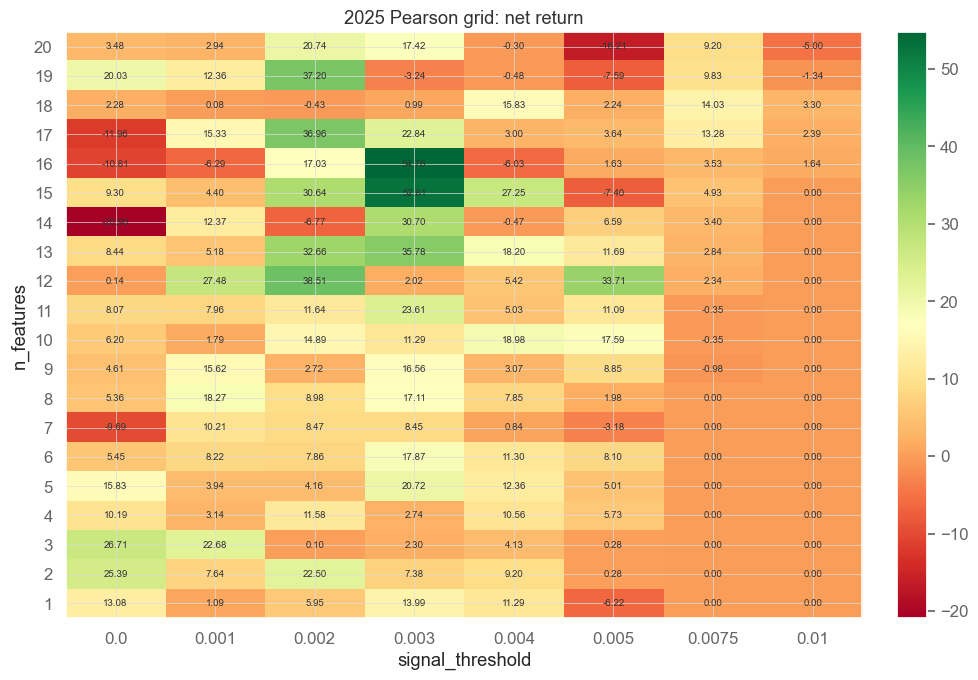

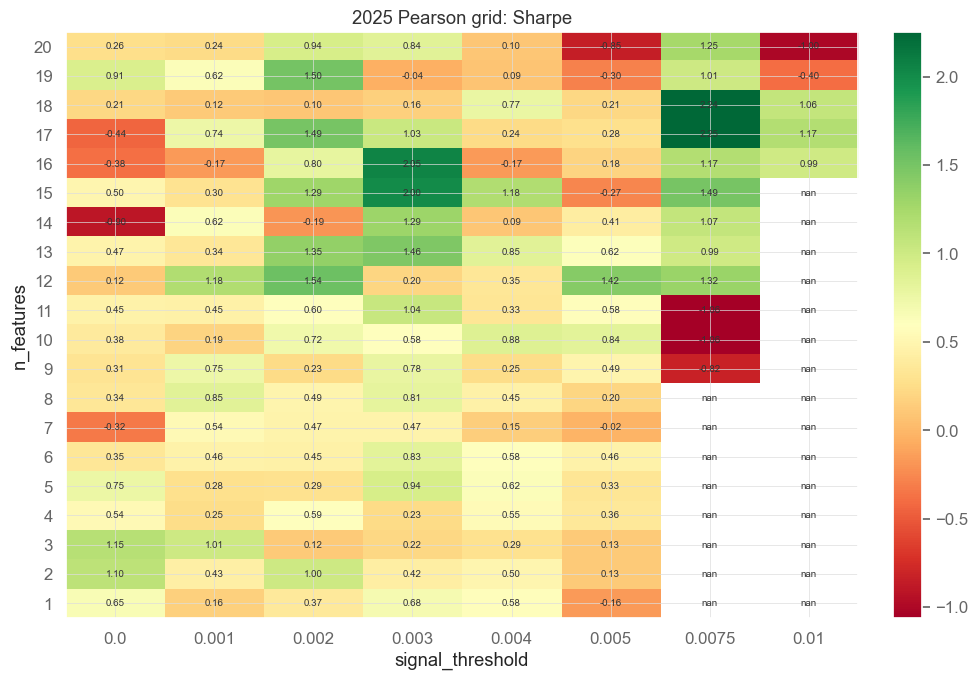

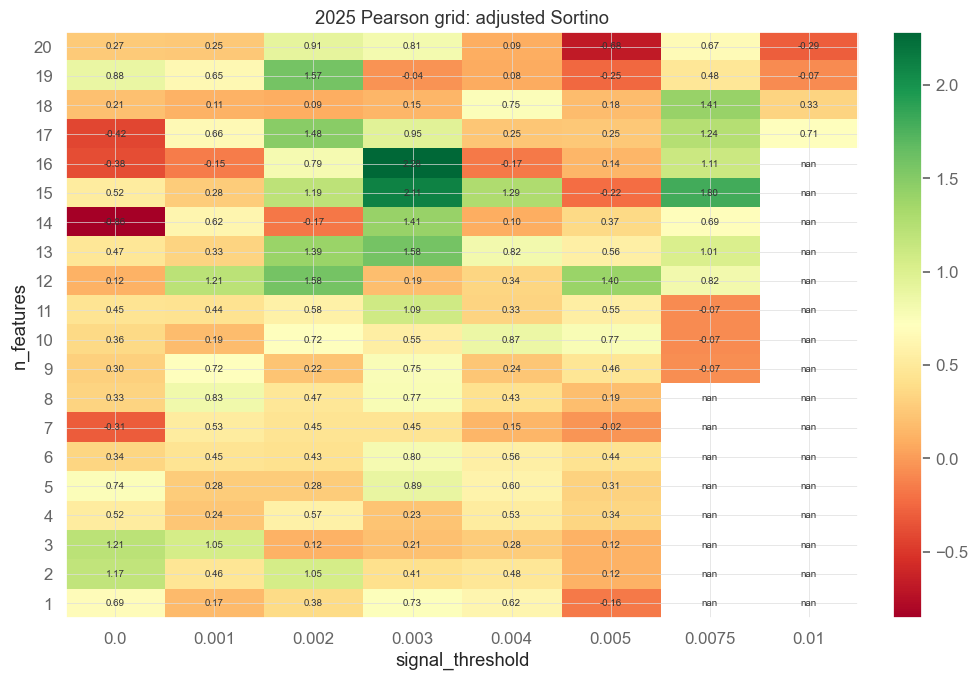

In [9]:
def plot_metric_grid(metrics_df: pd.DataFrame, metric: str, title: str | None = None):
    pivot = (
        metrics_df
        .pivot(index="n_features", columns="signal_threshold", values=metric)
        .sort_index(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_title(title or metric)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")

    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            value = pivot.values[y, x]
            label = "nan" if pd.isna(value) else f"{value:.2f}"
            ax.text(x, y, label, ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_core_heatmaps(metrics_df: pd.DataFrame, title_prefix: str):
    plot_metric_grid(metrics_df, "net_return_pct", f"{title_prefix}: net return")
    plot_metric_grid(metrics_df, "net_sharpe", f"{title_prefix}: Sharpe")
    plot_metric_grid(metrics_df, "adjusted_net_sortino", f"{title_prefix}: adjusted Sortino")


plot_core_heatmaps(metrics_df, "2025 Pearson grid")

### Feature Diagnostics for Candidate Runs


After the grid finishes, this section inspects the feature-selection behavior of the top three Sharpe performers. This is the Pearson analogue of the PCA loading review: instead of component loadings, we look at how frequently each feature was selected and how strong its absolute Pearson score was across rolling training windows.

Top Sharpe performer #1: ECH_features-17_sig-0p0075


run_id,ECH_features-17_sig-0p0075
grid_index,134
symbol,ECH
n_features,17
signal_threshold,0.0075
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,13.673266
net_return_pct,13.280875
benchmark_return_pct,65.173061


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
DEC_1,250,250,0.09871,0.09857,1.984,1,100.0
DEC_2,250,250,0.09871,0.09857,1.820,1,100.0
SDEC_2,250,250,0.09871,0.09857,2.484,1,100.0
INC_1,250,250,0.09665,0.09680,5.452,4,100.0
INC_2,250,250,0.09665,0.09680,5.056,4,100.0
SINC_2,250,250,0.09665,0.09680,5.512,4,100.0
BOP,250,250,0.09564,0.09500,5.692,1,100.0
CDL_LONGLINE,250,250,0.08498,0.08461,8.000,8,100.0
CDL_BELTHOLD,250,250,0.07579,0.07542,9.040,9,100.0


Top Sharpe performer #2: ECH_features-18_sig-0p0075


run_id,ECH_features-18_sig-0p0075
grid_index,142
symbol,ECH
n_features,18
signal_threshold,0.0075
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,14.691348
net_return_pct,14.034642
benchmark_return_pct,65.173061


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
DEC_1,250,250,0.09871,0.09857,1.984,1,100.0
DEC_2,250,250,0.09871,0.09857,1.820,1,100.0
SDEC_2,250,250,0.09871,0.09857,2.484,1,100.0
INC_1,250,250,0.09665,0.09680,5.452,4,100.0
INC_2,250,250,0.09665,0.09680,5.056,4,100.0
SINC_2,250,250,0.09665,0.09680,5.512,4,100.0
BOP,250,250,0.09564,0.09500,5.692,1,100.0
CDL_LONGLINE,250,250,0.08498,0.08461,8.000,8,100.0
CDL_BELTHOLD,250,250,0.07579,0.07542,9.040,9,100.0


Top Sharpe performer #3: ECH_features-16_sig-0p003


run_id,ECH_features-16_sig-0p003
grid_index,123
symbol,ECH
n_features,16
signal_threshold,0.003
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,60.582496
net_return_pct,54.76236
benchmark_return_pct,65.173061


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
BOP,250,250,0.09221,0.09227,1.000,1,100.0
CDL_LONGLINE,250,250,0.08430,0.08407,2.068,2,100.0
DEC_1,250,250,0.07778,0.07845,4.180,2,100.0
DEC_2,250,250,0.07778,0.07845,4.136,2,100.0
SDEC_2,250,250,0.07778,0.07845,4.728,3,100.0
CDL_BELTHOLD,250,250,0.07708,0.07754,4.996,2,100.0
INC_1,250,250,0.07341,0.07427,8.080,6,100.0
INC_2,250,250,0.07341,0.07427,7.740,6,100.0
SINC_2,250,250,0.07341,0.07427,8.072,6,100.0


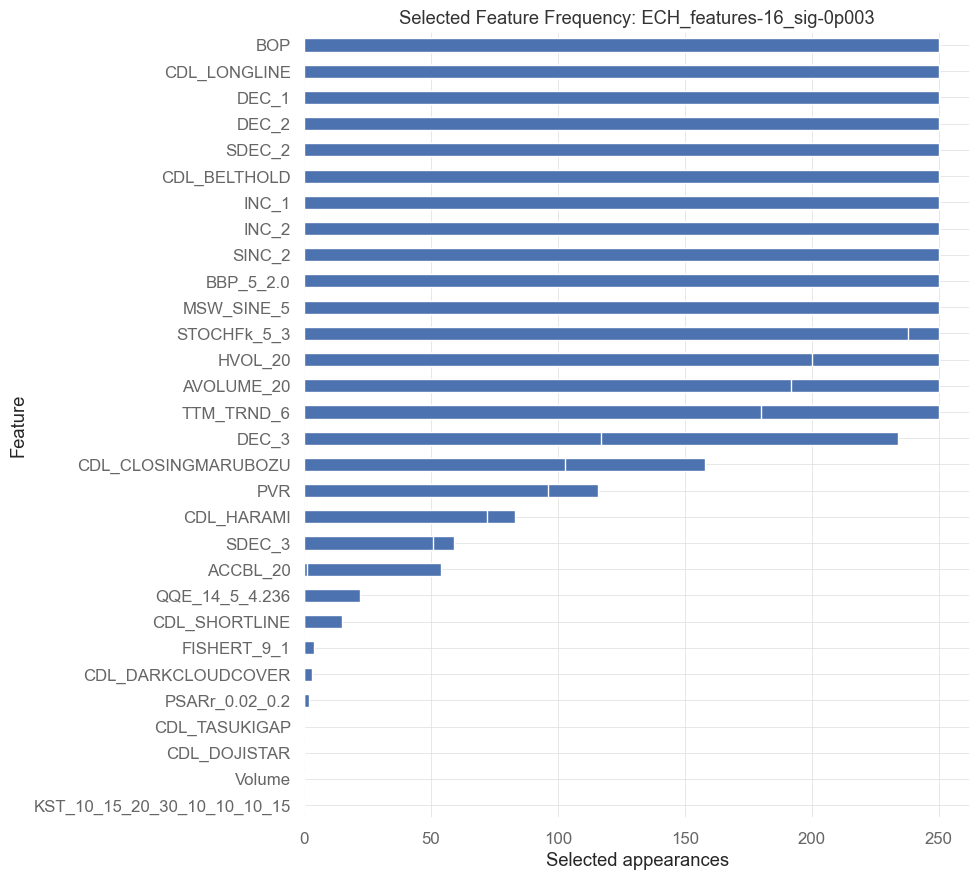

In [10]:
def show_top_feature_diagnostics(metrics_df: pd.DataFrame, grid_artifacts: dict, top_n_runs: int = 3, top_n_features: int = 40):
    top_run_ids = metrics_df.sort_values("net_sharpe", ascending=False).head(top_n_runs)["run_id"].tolist()

    for rank, run_id in enumerate(top_run_ids, start=1):
        artifacts = grid_artifacts[run_id]
        feature_summary = artifacts["feature_summary"]

        print(f"Top Sharpe performer #{rank}: {run_id}")
        display(pd.DataFrame([artifacts["metrics"]]).set_index("run_id").T)
        display(feature_summary.head(top_n_features).round(3))
        plot_selected_feature_frequency(feature_summary, top_n=30, title=f"Selected Feature Frequency: {run_id}")

    return top_run_ids


top_sharpe_run_ids = show_top_feature_diagnostics(metrics_df, grid_artifacts, top_n_runs=3)

In [11]:
def compare_feature_summaries(run_ids, grid_artifacts: dict, top_n: int = 40) -> pd.DataFrame:
    frames = []
    for run_id in run_ids:
        summary = grid_artifacts[run_id]["feature_summary"]
        if summary.empty:
            continue
        frame = summary[["selected_appearances", "selection_rate_pct", "mean_abs_corr", "mean_rank"]].copy()
        frame = frame.add_prefix(f"{run_id}__")
        frames.append(frame)

    if not frames:
        return pd.DataFrame()

    comparison = pd.concat(frames, axis=1).fillna(0)
    selected_cols = [col for col in comparison.columns if col.endswith("selected_appearances")]
    comparison["total_selected_appearances"] = comparison[selected_cols].sum(axis=1)
    return comparison.sort_values("total_selected_appearances", ascending=False).head(top_n)


feature_comparison = compare_feature_summaries(top_sharpe_run_ids, grid_artifacts, top_n=50)
display(feature_comparison.round(2))

,ECH_features-17_sig-0p0075__selected_appearances,ECH_features-17_sig-0p0075__selection_rate_pct,ECH_features-17_sig-0p0075__mean_abs_corr,ECH_features-17_sig-0p0075__mean_rank,ECH_features-18_sig-0p0075__selected_appearances,ECH_features-18_sig-0p0075__selection_rate_pct,ECH_features-18_sig-0p0075__mean_abs_corr,ECH_features-18_sig-0p0075__mean_rank,ECH_features-16_sig-0p003__selected_appearances,ECH_features-16_sig-0p003__selection_rate_pct,ECH_features-16_sig-0p003__mean_abs_corr,ECH_features-16_sig-0p003__mean_rank,total_selected_appearances
feature,,,,,,,,,,,,,
DEC_1,250,100.0,0.099,1.984,250,100.0,0.099,1.984,250,100.0,0.078,4.180,750
BBP_5_2.0,250,100.0,0.071,12.228,250,100.0,0.071,12.228,250,100.0,0.068,10.000,750
SDEC_2,250,100.0,0.099,2.484,250,100.0,0.099,2.484,250,100.0,0.078,4.728,750
INC_1,250,100.0,0.097,5.452,250,100.0,0.097,5.452,250,100.0,0.073,8.080,750
INC_2,250,100.0,0.097,5.056,250,100.0,0.097,5.056,250,100.0,0.073,7.740,750
SINC_2,250,100.0,0.097,5.512,250,100.0,0.097,5.512,250,100.0,0.073,8.072,750
BOP,250,100.0,0.096,5.692,250,100.0,0.096,5.692,250,100.0,0.092,1.000,750
CDL_LONGLINE,250,100.0,0.085,8.000,250,100.0,0.085,8.000,250,100.0,0.084,2.068,750
CDL_BELTHOLD,250,100.0,0.076,9.040,250,100.0,0.076,9.040,250,100.0,0.077,4.996,750


## Combined Strategy: Top 10 Net-Return Performers in 2025



This cell builds an equal-weight combined strategy from the top 10 Pearson grid performers ranked by `net_return_pct` in the 2025 candidate search. Each component strategy is rerun with `position_size=0.1`, the resulting target weights are summed into one combined ECH signal, and the combined portfolio is backtested as a single strategy.


📊 --- QUICK PORTFOLIO RESULTS: ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2025 ---
   Frictionless Return:     45.05%
   Net Strategy Return:     40.11%  (EW Benchmark: 65.17%)
   Max Drawdown:            -7.24%
   Win Rate (Gross Bars):   53.0%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  41.4%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  5.6%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      2.05    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        2.29    (EW Benchmark: 2.67)
   Total Fees Paid:         $49,369.16
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


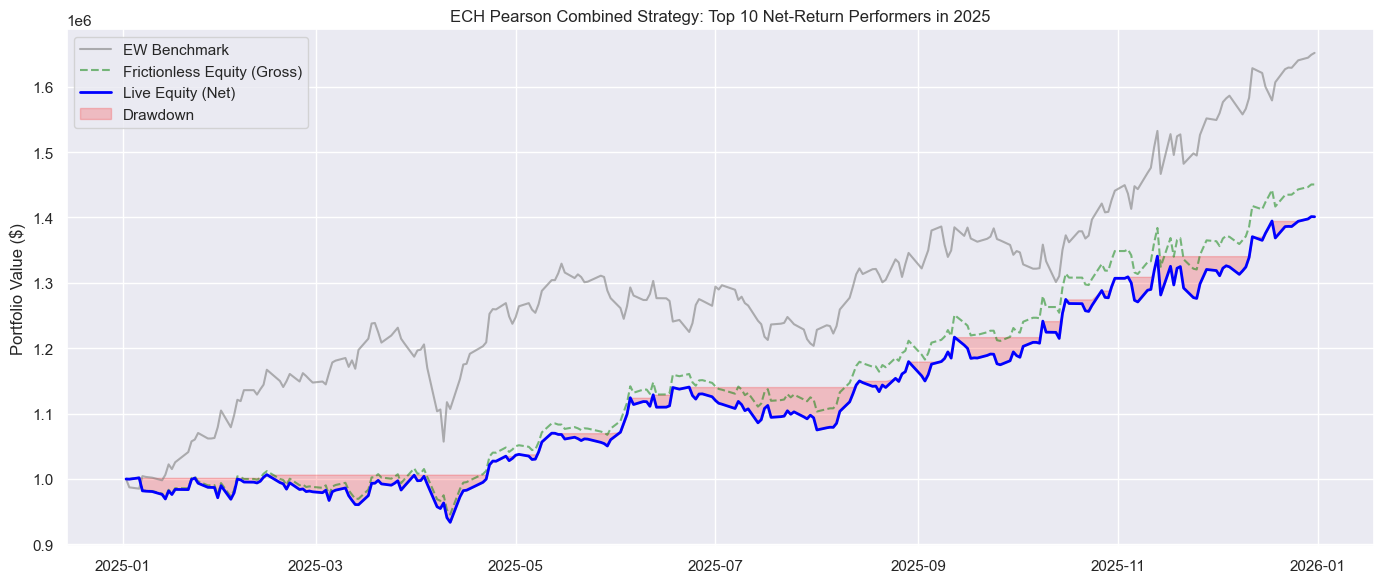

,grid_index,run_id,n_features,signal_threshold,position_size
0,123,ECH_features-16_sig-0p003,16,0.003,0.1
1,115,ECH_features-15_sig-0p003,15,0.003,0.1
2,90,ECH_features-12_sig-0p002,12,0.002,0.1
3,146,ECH_features-19_sig-0p002,19,0.002,0.1
4,130,ECH_features-17_sig-0p002,17,0.002,0.1
5,99,ECH_features-13_sig-0p003,13,0.003,0.1
6,93,ECH_features-12_sig-0p005,12,0.005,0.1
7,98,ECH_features-13_sig-0p002,13,0.002,0.1
8,107,ECH_features-14_sig-0p003,14,0.003,0.1
9,114,ECH_features-15_sig-0p002,15,0.002,0.1


,ECH_features-16_sig-0p003,ECH_features-15_sig-0p003,ECH_features-12_sig-0p002,ECH_features-19_sig-0p002,ECH_features-17_sig-0p002,ECH_features-13_sig-0p003,ECH_features-12_sig-0p005,ECH_features-13_sig-0p002,ECH_features-14_sig-0p003,ECH_features-15_sig-0p002
Timestamp,,,,,,,,,,
2025-01-02,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1
2025-01-03,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1
2025-01-06,-0.1,0.1,0.1,0.1,0.1,-0.1,0.1,0.1,-0.1,0.1
2025-01-07,-0.1,0.1,0.1,-0.1,-0.1,0.1,0.1,0.1,0.1,0.1
2025-01-08,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


,ECH
Timestamp,
2025-01-02,-1.0
2025-01-03,-1.0
2025-01-06,0.4
2025-01-07,0.4
2025-01-08,1.0


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2025-12-24,5.019238e-05,1.434893e+06,269.80751,48726.873630,1.386166e+06,-0.000143,1.628892
2025-12-26,5.623877e-03,1.442963e+06,53.78837,48780.661999,1.394182e+06,0.005783,1.640343
2025-12-29,2.493106e-03,1.446560e+06,0.00000,48780.661999,1.397780e+06,0.002580,1.644432
2025-12-30,2.694096e-03,1.450457e+06,317.51002,49098.172019,1.401359e+06,0.002561,1.648862
2025-12-31,4.828235e-20,1.450457e+06,270.98473,49369.156749,1.401088e+06,-0.000193,1.651731


In [18]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows = metrics_df.sort_values("net_return_pct", ascending=False).head(10)

combined_specs_2025_top10 = []
for grid_index, row in top_10_return_rows.iterrows():
    combined_specs_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2025_top10 = {}
combined_weights_parts_2025_top10 = []

for spec in combined_specs_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS_2025["start_date"],
        end_date=COMMON_PARAMS_2025["end_date"],
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2025_top10[run_id] = artifacts
    combined_weights_parts_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2025_top10 = pd.concat(combined_weights_parts_2025_top10, axis=1).fillna(0)

combined_weights_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2025_top10.sum(axis=1)},
    index=combined_component_weights_2025_top10.index,
)

combined_prices_2025_top10 = (
    next(iter(combined_artifacts_2025_top10.values()))["prices"]
    .loc[combined_weights_2025_top10.index]
)

combined_engine_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2025_top10,
    signals=combined_weights_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2025_top10 = combined_engine_2025_top10.run()
combined_engine_2025_top10.tearsheet("ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2025")

combined_strategy_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2025_top10,
    "component_artifacts": combined_artifacts_2025_top10,
    "component_weights": combined_component_weights_2025_top10,
    "weights": combined_weights_2025_top10,
    "prices": combined_prices_2025_top10,
    "engine": combined_engine_2025_top10,
    "stats": combined_stats_2025_top10,
}

display(pd.DataFrame(combined_specs_2025_top10))
display(combined_component_weights_2025_top10.head())
display(combined_weights_2025_top10.head())
display(combined_stats_2025_top10.tail())

Now test how this combined strategy would work on `2026 – YTD`


📊 --- QUICK PORTFOLIO RESULTS: ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2025 ---
   Frictionless Return:     2.53%
   Net Strategy Return:     0.60%  (EW Benchmark: -1.03%)
   Max Drawdown:            -20.42%
   Win Rate (Gross Bars):   45.9%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  48.4%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  5.7%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      0.18    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        0.19    (EW Benchmark: 0.12)
   Total Fees Paid:         $19,287.84
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


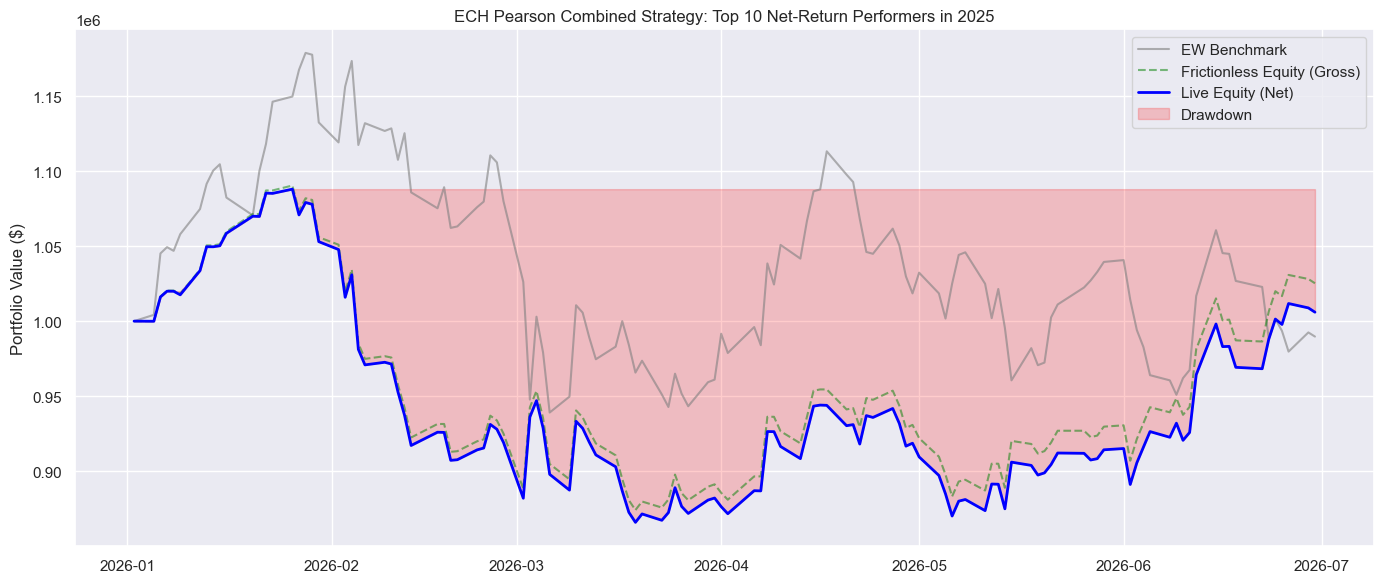

,grid_index,run_id,n_features,signal_threshold,position_size
0,123,ECH_features-16_sig-0p003,16,0.003,0.1
1,115,ECH_features-15_sig-0p003,15,0.003,0.1
2,90,ECH_features-12_sig-0p002,12,0.002,0.1
3,146,ECH_features-19_sig-0p002,19,0.002,0.1
4,130,ECH_features-17_sig-0p002,17,0.002,0.1
5,99,ECH_features-13_sig-0p003,13,0.003,0.1
6,93,ECH_features-12_sig-0p005,12,0.005,0.1
7,98,ECH_features-13_sig-0p002,13,0.002,0.1
8,107,ECH_features-14_sig-0p003,14,0.003,0.1
9,114,ECH_features-15_sig-0p002,15,0.002,0.1


,ECH_features-16_sig-0p003,ECH_features-15_sig-0p003,ECH_features-12_sig-0p002,ECH_features-19_sig-0p002,ECH_features-17_sig-0p002,ECH_features-13_sig-0p003,ECH_features-12_sig-0p005,ECH_features-13_sig-0p002,ECH_features-14_sig-0p003,ECH_features-15_sig-0p002
Timestamp,,,,,,,,,,
2026-01-02,0.1,0.1,0.1,0.1,-0.1,0.1,-0.1,0.1,-0.1,0.1
2026-01-05,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-06,-0.1,-0.1,0.1,0.1,0.1,-0.1,0.1,0.1,-0.1,-0.1
2026-01-07,-0.1,-0.1,0.1,-0.1,0.1,-0.1,-0.1,0.1,-0.1,0.1
2026-01-08,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


,ECH
Timestamp,
2026-01-02,0.4
2026-01-05,1.0
2026-01-06,0.0
2026-01-07,-0.2
2026-01-08,1.0


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,0.013445,1.019971e+06,134.369754,18590.668332,1.001380e+06,0.013560,1.001498
2026-06-25,-0.003204,1.016703e+06,313.147590,18903.815922,9.977990e+05,-0.003576,0.993476
2026-06-26,0.013878,1.030813e+06,150.971182,19054.787104,1.011758e+06,0.013990,0.979689
2026-06-29,-0.002610,1.028123e+06,233.053824,19287.840929,1.008835e+06,-0.002890,0.992474
2026-06-30,-0.002778,1.025266e+06,0.000000,19287.840929,1.005978e+06,-0.002832,0.989716


In [19]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows = metrics_df.sort_values("net_return_pct", ascending=False).head(10)

combined_specs_2025_top10 = []
for grid_index, row in top_10_return_rows.iterrows():
    combined_specs_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2025_top10 = {}
combined_weights_parts_2025_top10 = []

for spec in combined_specs_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        # start_date=COMMON_PARAMS_2025["start_date"],
        start_date="2026-01-01",
        # end_date=COMMON_PARAMS_2025["end_date"],
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2025_top10[run_id] = artifacts
    combined_weights_parts_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2025_top10 = pd.concat(combined_weights_parts_2025_top10, axis=1).fillna(0)

combined_weights_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2025_top10.sum(axis=1)},
    index=combined_component_weights_2025_top10.index,
)

combined_prices_2025_top10 = (
    next(iter(combined_artifacts_2025_top10.values()))["prices"]
    .loc[combined_weights_2025_top10.index]
)

combined_engine_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2025_top10,
    signals=combined_weights_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2025_top10 = combined_engine_2025_top10.run()
combined_engine_2025_top10.tearsheet("ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2025")

combined_strategy_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2025_top10,
    "component_artifacts": combined_artifacts_2025_top10,
    "component_weights": combined_component_weights_2025_top10,
    "weights": combined_weights_2025_top10,
    "prices": combined_prices_2025_top10,
    "engine": combined_engine_2025_top10,
    "stats": combined_stats_2025_top10,
}

display(pd.DataFrame(combined_specs_2025_top10))
display(combined_component_weights_2025_top10.head())
display(combined_weights_2025_top10.head())
display(combined_stats_2025_top10.tail())

Seems like this combined strategy would perform terribly out of sample :(

## Second Candidate Search: Test Top Combined Strategy For 2023-2025 On 2026-YTD

This duplicates the Pearson grid-search workflow for a longer candidate-selection window: `2023-01-01` to `2026-01-01`. The purpose is to find parameter sets that performed well across 2023-2025 before we later test selected combined-strategy candidates on 2026-YTD data.

### 2023-2025 Grid search

In [12]:
metrics_df_2023_2025, errors_df_2023_2025, grid_artifacts_2023_2025 = run_grid_search(
    COMMON_PARAMS_2023_2025,
    OUTPUT_DIR_2023_2025,
)
show_leaderboards(
    metrics_df_2023_2025,
    errors_df_2023_2025,
    title="Test top combined strategy for 2023-2025 on 2026-YTD",
)

Total cases: 160


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


Running grid_index=0: ECH_features-1_sig-0
Running grid_index=1: ECH_features-1_sig-0p001
Running grid_index=2: ECH_features-1_sig-0p002
Running grid_index=3: ECH_features-1_sig-0p003
Running grid_index=4: ECH_features-1_sig-0p004
Running grid_index=5: ECH_features-1_sig-0p005
Running grid_index=6: ECH_features-1_sig-0p0075
Running grid_index=7: ECH_features-1_sig-0p01
Running grid_index=8: ECH_features-2_sig-0
Running grid_index=9: ECH_features-2_sig-0p001
Running grid_index=10: ECH_features-2_sig-0p002
Running grid_index=11: ECH_features-2_sig-0p003
Running grid_index=12: ECH_features-2_sig-0p004
Running grid_index=13: ECH_features-2_sig-0p005
Running grid_index=14: ECH_features-2_sig-0p0075


[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:  3.4min


Running grid_index=15: ECH_features-2_sig-0p01
Running grid_index=16: ECH_features-3_sig-0
Running grid_index=18: ECH_features-3_sig-0p002
Running grid_index=17: ECH_features-3_sig-0p001
Running grid_index=19: ECH_features-3_sig-0p003
Running grid_index=20: ECH_features-3_sig-0p004
Running grid_index=21: ECH_features-3_sig-0p005
Running grid_index=22: ECH_features-3_sig-0p0075
Running grid_index=23: ECH_features-3_sig-0p01
Running grid_index=24: ECH_features-4_sig-0


...

Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
115,ECH_features-15_sig-0p003,15,0.003,1.3284,1.4456,133.5690,157.1246,67.4697,-19.5328,235556.1818,98.5372,0.9854,0.8590,53.3955,43.9414,2.6631,44.0160,1.4628,54.5213,325266,24,0.0781
123,ECH_features-16_sig-0p003,16,0.003,1.2133,1.3437,116.5461,138.2427,50.4467,-21.9059,216966.7936,99.0691,0.9907,0.8644,52.8628,45.0067,2.1305,46.4096,0.9309,52.6596,325266,26,0.0770
131,ECH_features-17_sig-0p003,17,0.003,1.1940,1.2537,112.2787,137.8457,46.1794,-20.8224,255669.4927,98.0053,0.9801,0.8830,51.2650,45.5393,3.1957,47.6064,1.9947,50.3989,325266,28,0.0759
16,ECH_features-3_sig-0,3,0.000,1.1430,1.2783,108.0498,134.2957,41.9504,-18.9865,262459.0331,100.0000,1.0000,0.9069,51.9308,46.8708,1.1984,42.9521,0.0000,57.0479,325266,5,0.1040
107,ECH_features-14_sig-0p003,14,0.003,1.1401,1.2692,105.7560,129.4759,39.6566,-23.4159,237199.0307,99.3351,0.9934,0.8590,52.9960,45.1398,1.8642,46.8085,0.6649,52.5266,325266,22,0.0794
90,ECH_features-12_sig-0p002,12,0.002,1.1226,1.2036,104.2688,126.2897,38.1695,-28.5574,220208.2715,100.0000,1.0000,0.8590,52.5965,46.2051,1.1984,41.7553,0.0000,58.2447,325266,17,0.0907
98,ECH_features-13_sig-0p002,13,0.002,1.0409,1.1388,93.1631,115.1276,27.0638,-25.5045,219645.3706,100.0000,1.0000,0.8590,51.5313,47.2703,1.1984,42.1543,0.0000,57.8457,325266,18,0.0892
116,ECH_features-15_sig-0p004,15,0.004,0.9161,1.0026,74.6460,96.8526,8.5466,-29.0300,222066.7313,95.3457,0.9535,0.8803,49.4008,45.0067,5.5925,45.4787,4.6543,49.8670,325266,27,0.0820
8,ECH_features-2_sig-0,2,0.000,0.8418,0.9419,68.3583,92.2022,2.2589,-21.6646,238439.3057,100.0000,1.0000,0.9601,51.7976,47.0040,1.1984,44.9468,0.0000,55.0532,325266,4,0.1074


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
135,ECH_features-17_sig-0p01,17,0.0100,0.6073,0.1789,4.3751,4.9313,-61.7242,-2.5575,5561.9368,1.4628,0.0146,0.0293,0.6658,0.7989,98.5353,0.2660,98.5372,1.1968,325266,31,0.0720
118,ECH_features-15_sig-0p0075,15,0.0075,0.6302,0.2192,6.4881,7.7653,-59.6113,-2.5853,12772.4505,3.3245,0.0332,0.0665,1.7310,1.4647,96.8043,1.3298,96.6755,1.9947,325266,20,0.0905
70,ECH_features-9_sig-0p0075,9,0.0075,-0.6574,-0.0639,-2.7442,-2.3515,-68.8435,-2.7442,3927.6036,1.0638,0.0106,0.0213,0.5326,0.3995,99.0679,0.0000,98.9362,1.0638,325266,14,0.1005
142,ECH_features-18_sig-0p0075,18,0.0075,2.3174,1.6177,51.3720,54.9994,-14.7273,-3.0537,36273.9498,9.3085,0.0931,0.1516,6.6578,2.3968,90.9454,3.0585,90.6915,6.2500,325266,28,0.0866
94,ECH_features-12_sig-0p0075,12,0.0075,-0.1590,-0.0184,-0.8600,-0.4772,-66.9593,-3.3674,3828.0892,1.0638,0.0106,0.0213,0.6658,0.3995,98.9348,0.0000,98.9362,1.0638,325266,15,0.0951
126,ECH_features-16_sig-0p0075,16,0.0075,0.4991,0.1716,4.3276,5.3142,-61.7717,-3.8845,9865.4995,2.5266,0.0253,0.0505,1.1984,1.1984,97.6032,0.7979,97.4734,1.7287,325266,21,0.0893
102,ECH_features-13_sig-0p0075,13,0.0075,0.5762,0.2097,5.3711,6.4661,-60.7282,-3.8880,10950.3045,2.7926,0.0279,0.0559,1.4647,1.1984,97.3369,0.6649,97.2074,2.1277,325266,16,0.0936
110,ECH_features-14_sig-0p0075,14,0.0075,0.6820,0.2566,7.7819,9.3043,-58.3175,-3.8952,15224.0230,3.8564,0.0386,0.0771,2.2636,1.4647,96.2716,1.0638,96.1436,2.7926,325266,18,0.0920
134,ECH_features-17_sig-0p0075,17,0.0075,1.2239,0.5382,23.5105,25.7510,-42.5888,-4.8711,22405.0897,7.4468,0.0745,0.1090,4.5273,2.7963,92.6764,2.1277,92.5532,5.3191,325266,25,0.0880


""


### 2023-2025 Heatmaps

The same core heatmaps are shown for the longer window: net return, Sharpe, and adjusted Sortino.

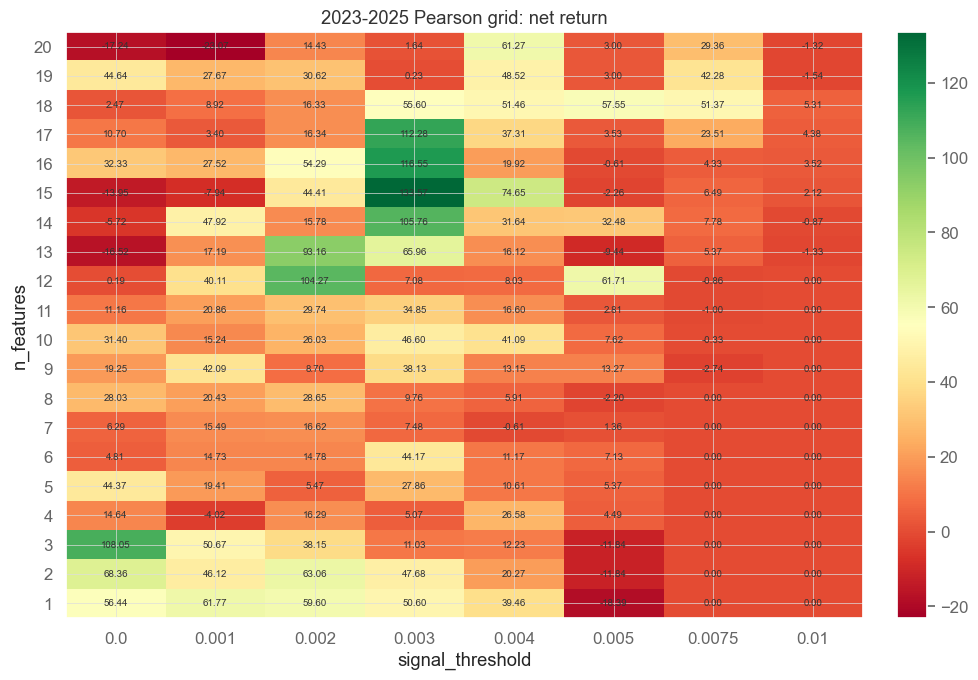

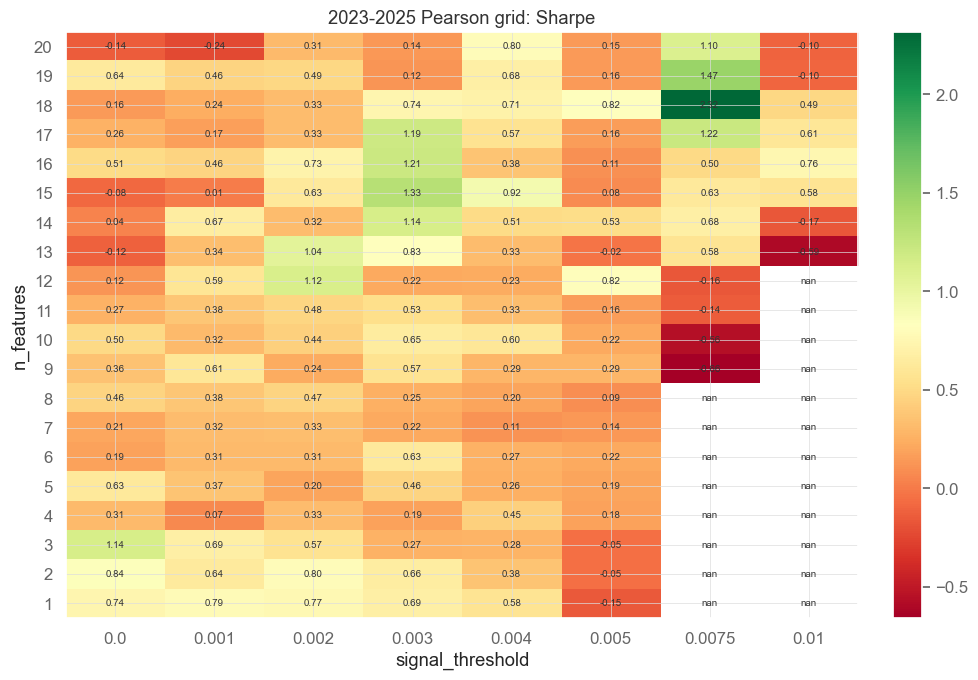

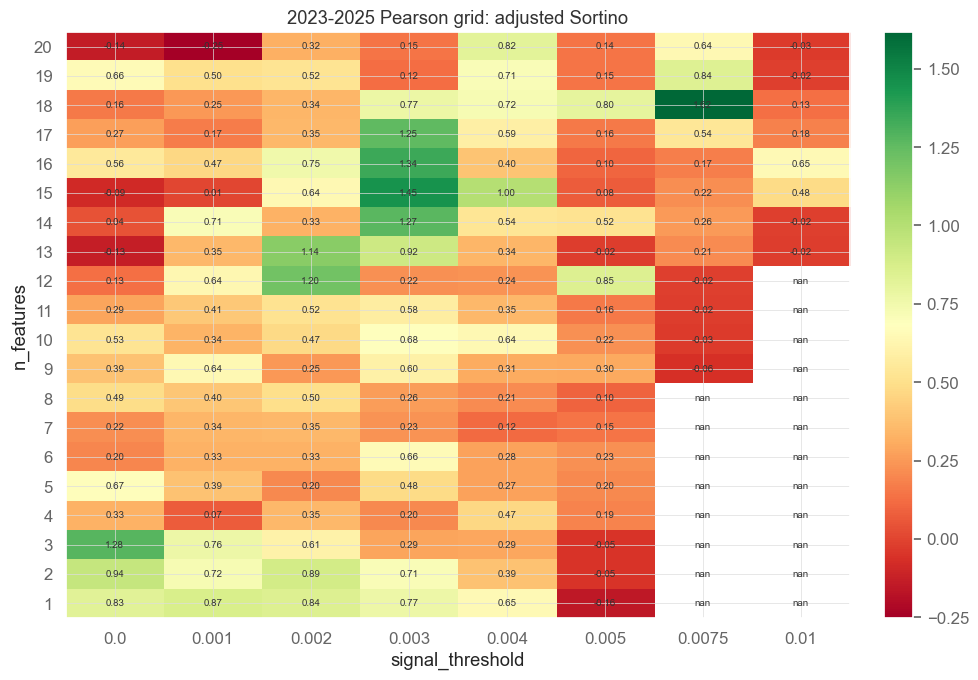

In [13]:
plot_core_heatmaps(metrics_df_2023_2025, "2023-2025 Pearson grid")

### 2023-2025 Feature Diagnostics For Top Sharpe Performers

These diagnostics inspect the top three Sharpe performers in the longer candidate-selection window.

Top Sharpe performer #1: ECH_features-18_sig-0p0075


run_id,ECH_features-18_sig-0p0075
grid_index,142
symbol,ECH
n_features,18
signal_threshold,0.0075
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,54.999439
net_return_pct,51.372044
benchmark_return_pct,66.099331


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
DEC_1,752,752,0.10667,0.10870,1.97606,1,100.00000
DEC_2,752,752,0.10667,0.10870,1.81383,1,100.00000
SDEC_2,752,752,0.10667,0.10870,2.30585,1,100.00000
INC_1,752,752,0.10483,0.10672,5.09840,4,100.00000
INC_2,752,752,0.10483,0.10672,5.16489,4,100.00000
SINC_2,752,752,0.10483,0.10672,5.23936,4,100.00000
BOP,752,752,0.10018,0.10096,6.40160,1,100.00000
CDL_LONGLINE,752,752,0.08671,0.08619,8.53059,8,100.00000
CDL_BELTHOLD,752,752,0.08033,0.07936,10.92686,8,100.00000


Top Sharpe performer #2: ECH_features-19_sig-0p0075


run_id,ECH_features-19_sig-0p0075
grid_index,150
symbol,ECH
n_features,19
signal_threshold,0.0075
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,46.869835
net_return_pct,42.276983
benchmark_return_pct,66.099331


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
DEC_1,752,752,0.10667,0.10870,1.97606,1,100.00000
DEC_2,752,752,0.10667,0.10870,1.81383,1,100.00000
SDEC_2,752,752,0.10667,0.10870,2.30585,1,100.00000
INC_1,752,752,0.10483,0.10672,5.09840,4,100.00000
INC_2,752,752,0.10483,0.10672,5.16489,4,100.00000
SINC_2,752,752,0.10483,0.10672,5.23936,4,100.00000
BOP,752,752,0.10018,0.10096,6.40160,1,100.00000
CDL_LONGLINE,752,752,0.08671,0.08619,8.53059,8,100.00000
CDL_BELTHOLD,752,752,0.08033,0.07936,10.92686,8,100.00000


Top Sharpe performer #3: ECH_features-15_sig-0p003


run_id,ECH_features-15_sig-0p003
grid_index,115
symbol,ECH
n_features,15
signal_threshold,0.003
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,157.124649
net_return_pct,133.569031
benchmark_return_pct,66.099331


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
BOP,752,752,0.09897,0.09986,1.00000,1,100.00000
DEC_1,752,752,0.08759,0.08947,3.53324,2,100.00000
DEC_2,752,752,0.08759,0.08947,3.64495,2,100.00000
SDEC_2,752,752,0.08759,0.08947,3.92420,2,100.00000
CDL_LONGLINE,752,752,0.08423,0.08465,6.05718,2,100.00000
CDL_BELTHOLD,752,752,0.08382,0.08375,5.78059,2,100.00000
INC_1,752,752,0.08339,0.08421,7.15293,5,100.00000
INC_2,752,752,0.08339,0.08421,7.07979,5,100.00000
SINC_2,752,752,0.08339,0.08421,7.21410,5,100.00000


,ECH_features-18_sig-0p0075__selected_appearances,ECH_features-18_sig-0p0075__selection_rate_pct,ECH_features-18_sig-0p0075__mean_abs_corr,ECH_features-18_sig-0p0075__mean_rank,ECH_features-19_sig-0p0075__selected_appearances,ECH_features-19_sig-0p0075__selection_rate_pct,ECH_features-19_sig-0p0075__mean_abs_corr,ECH_features-19_sig-0p0075__mean_rank,ECH_features-15_sig-0p003__selected_appearances,ECH_features-15_sig-0p003__selection_rate_pct,ECH_features-15_sig-0p003__mean_abs_corr,ECH_features-15_sig-0p003__mean_rank,total_selected_appearances
feature,,,,,,,,,,,,,
DEC_1,752,100.000,0.107,1.976,752,100.000,0.107,1.976,752,100.000,0.088,3.533,2256
SDEC_2,752,100.000,0.107,2.306,752,100.000,0.107,2.306,752,100.000,0.088,3.924,2256
INC_1,752,100.000,0.105,5.098,752,100.000,0.105,5.098,752,100.000,0.083,7.153,2256
INC_2,752,100.000,0.105,5.165,752,100.000,0.105,5.165,752,100.000,0.083,7.080,2256
SINC_2,752,100.000,0.105,5.239,752,100.000,0.105,5.239,752,100.000,0.083,7.214,2256
BOP,752,100.000,0.100,6.402,752,100.000,0.100,6.402,752,100.000,0.099,1.000,2256
CDL_LONGLINE,752,100.000,0.087,8.531,752,100.000,0.087,8.531,752,100.000,0.084,6.057,2256
CDL_BELTHOLD,752,100.000,0.080,10.927,752,100.000,0.080,10.927,752,100.000,0.084,5.781,2256
BBP_5_2.0,752,100.000,0.077,11.702,752,100.000,0.077,11.702,752,100.000,0.076,9.632,2256


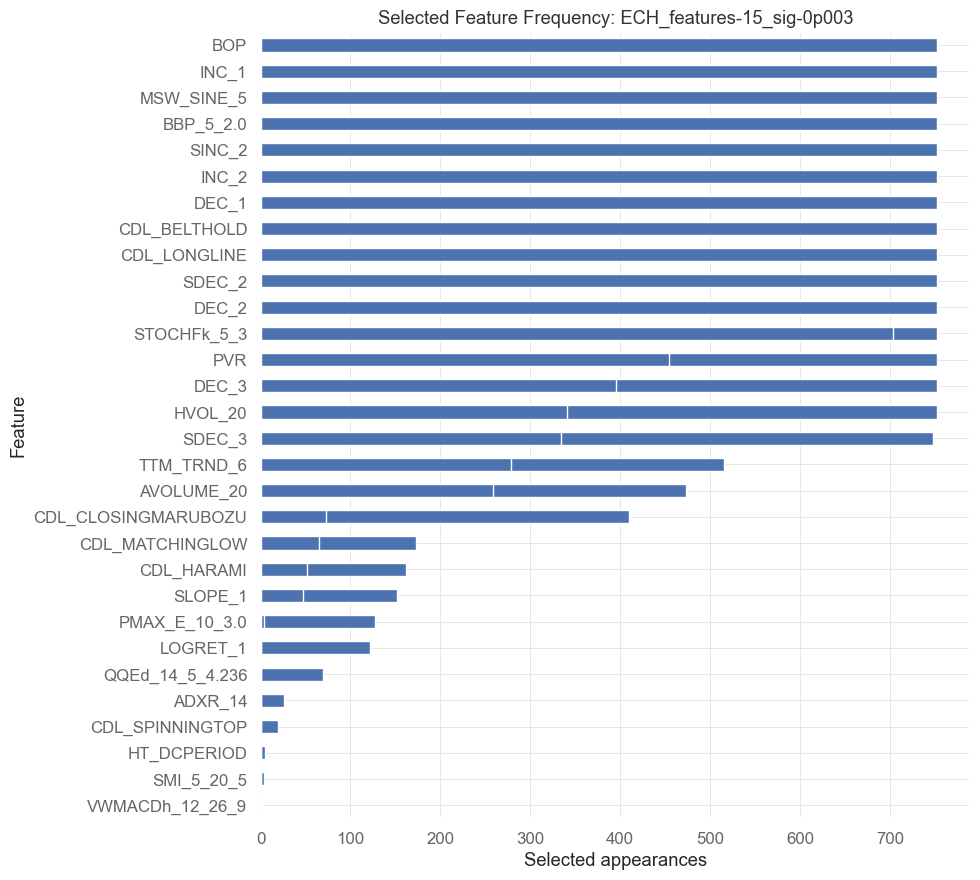

In [14]:
top_sharpe_run_ids_2023_2025 = show_top_feature_diagnostics(
    metrics_df_2023_2025,
    grid_artifacts_2023_2025,
    top_n_runs=3,
)

feature_comparison_2023_2025 = compare_feature_summaries(
    top_sharpe_run_ids_2023_2025,
    grid_artifacts_2023_2025,
    top_n=50,
)
display(feature_comparison_2023_2025.round(3))

## Combined Strategy: Top 10 Net-Return Performers in 2023-2025



This cell builds an equal-weight combined strategy from the top 10 Pearson grid performers ranked by `net_return_pct` in the 2023-2025 candidate search. Each component strategy is rerun with `position_size=0.1`, the resulting target weights are summed into one combined ECH signal, and the combined portfolio is backtested as a single strategy.


📊 --- QUICK PORTFOLIO RESULTS: ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025 ---
   Frictionless Return:     125.87%
   Net Strategy Return:     104.79%  (EW Benchmark: 66.10%)
   Max Drawdown:            -20.74%
   Win Rate (Gross Bars):   51.7%   (EW Benchmark: 51.1%)
   Loss Rate (Gross Bars):  44.9%   (EW Benchmark: 47.8%)
   Zero Rate (Gross Bars):  3.5%    (EW Benchmark: 1.1%)
   Sharpe Ratio (Net):      1.37    (EW Benchmark: 0.87)
   Sortino/√2 (Net):        1.49    (EW Benchmark: 0.89)
   Total Fees Paid:         $210,843.21
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2023-2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


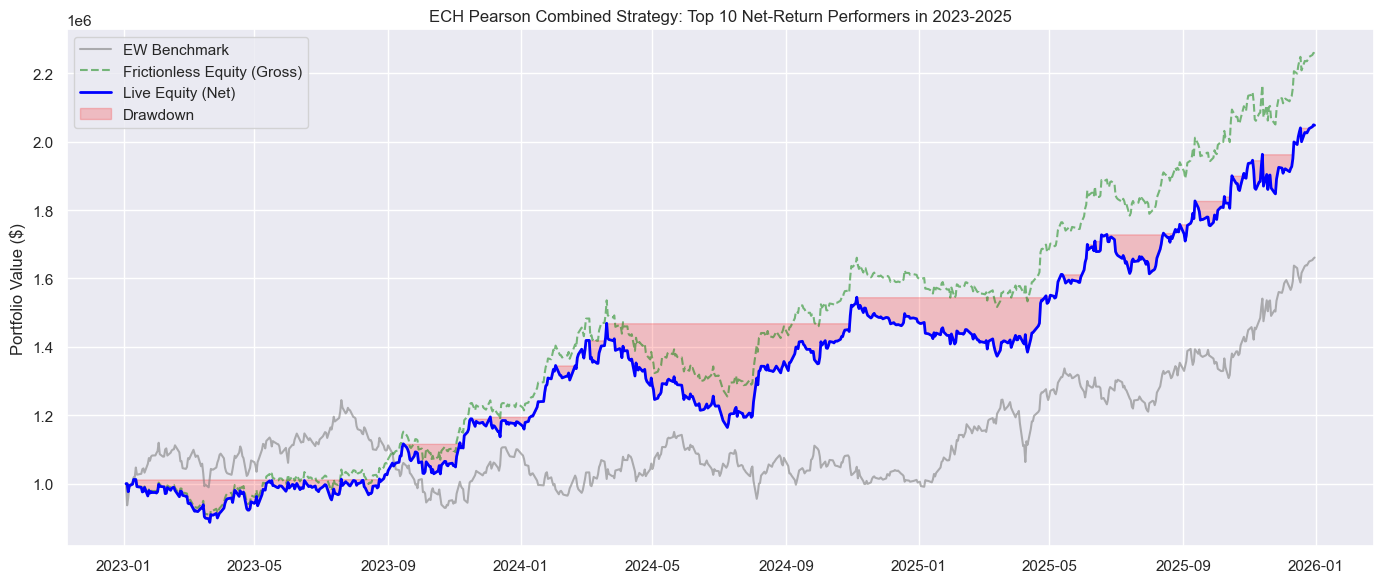

,grid_index,run_id,n_features,signal_threshold,position_size
0,115,ECH_features-15_sig-0p003,15,0.003,0.1
1,123,ECH_features-16_sig-0p003,16,0.003,0.1
2,131,ECH_features-17_sig-0p003,17,0.003,0.1
3,16,ECH_features-3_sig-0,3,0.000,0.1
4,107,ECH_features-14_sig-0p003,14,0.003,0.1
5,90,ECH_features-12_sig-0p002,12,0.002,0.1
6,98,ECH_features-13_sig-0p002,13,0.002,0.1
7,116,ECH_features-15_sig-0p004,15,0.004,0.1
8,8,ECH_features-2_sig-0,2,0.000,0.1
9,99,ECH_features-13_sig-0p003,13,0.003,0.1


,ECH_features-15_sig-0p003,ECH_features-16_sig-0p003,ECH_features-17_sig-0p003,ECH_features-3_sig-0,ECH_features-14_sig-0p003,ECH_features-12_sig-0p002,ECH_features-13_sig-0p002,ECH_features-15_sig-0p004,ECH_features-2_sig-0,ECH_features-13_sig-0p003
Timestamp,,,,,,,,,,
2023-01-03,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1
2023-01-04,0.1,0.1,-0.1,0.1,0.1,0.1,0.1,0.0,0.1,-0.1
2023-01-05,0.1,0.1,-0.1,0.1,-0.1,0.1,0.1,0.1,0.1,-0.1
2023-01-06,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2023-01-09,0.1,0.1,0.1,0.1,0.1,-0.1,0.1,0.1,0.1,0.1


,ECH
Timestamp,
2023-01-03,-1.0
2023-01-04,0.5
2023-01-05,0.4
2023-01-06,1.0
2023-01-09,0.8


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2025-12-24,6.965592e-21,2.235251e+06,336.261260,209662.213133,2.025588e+06,-0.000166,1.638026
2025-12-26,5.623877e-03,2.247821e+06,83.790550,209746.003682,2.038075e+06,0.006165,1.649541
2025-12-29,2.493106e-03,2.253425e+06,0.000000,209746.003682,2.043679e+06,0.002750,1.653654
2025-12-30,2.694096e-03,2.259496e+06,590.648461,210336.652144,2.049160e+06,0.002682,1.658109
2025-12-31,-3.479110e-04,2.258710e+06,506.562134,210843.214278,2.047867e+06,-0.000631,1.660993


In [20]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows_2023_2025 = (
    metrics_df_2023_2025
    .sort_values("net_return_pct", ascending=False)
    .head(10)
)

combined_specs_2023_2025_top10 = []
for grid_index, row in top_10_return_rows_2023_2025.iterrows():
    combined_specs_2023_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2023_2025_top10 = {}
combined_weights_parts_2023_2025_top10 = []

for spec in combined_specs_2023_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS_2023_2025["start_date"],
        end_date=COMMON_PARAMS_2023_2025["end_date"],
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2023_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2023_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2023_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2023_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2023_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2023_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2023_2025_top10[run_id] = artifacts
    combined_weights_parts_2023_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2023_2025_top10 = pd.concat(
    combined_weights_parts_2023_2025_top10,
    axis=1,
).fillna(0)

combined_weights_2023_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2023_2025_top10.sum(axis=1)},
    index=combined_component_weights_2023_2025_top10.index,
)

combined_prices_2023_2025_top10 = (
    next(iter(combined_artifacts_2023_2025_top10.values()))["prices"]
    .loc[combined_weights_2023_2025_top10.index]
)

combined_engine_2023_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2023_2025_top10,
    signals=combined_weights_2023_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2023_2025_top10 = combined_engine_2023_2025_top10.run()
combined_engine_2023_2025_top10.tearsheet(
    "ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025"
)

combined_strategy_2023_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2023_2025_top10,
    "component_artifacts": combined_artifacts_2023_2025_top10,
    "component_weights": combined_component_weights_2023_2025_top10,
    "weights": combined_weights_2023_2025_top10,
    "prices": combined_prices_2023_2025_top10,
    "engine": combined_engine_2023_2025_top10,
    "stats": combined_stats_2023_2025_top10,
}

display(pd.DataFrame(combined_specs_2023_2025_top10))
display(combined_component_weights_2023_2025_top10.head())
display(combined_weights_2023_2025_top10.head())
display(combined_stats_2023_2025_top10.tail())

Now test how this combined strategy would work on `2026 – YTD`


📊 --- QUICK PORTFOLIO RESULTS: ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025 ---
   Frictionless Return:     11.82%
   Net Strategy Return:     9.81%  (EW Benchmark: -1.03%)
   Max Drawdown:            -17.09%
   Win Rate (Gross Bars):   50.8%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  46.7%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  2.5%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      0.88    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        0.98    (EW Benchmark: 0.12)
   Total Fees Paid:         $20,077.76
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2023-2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


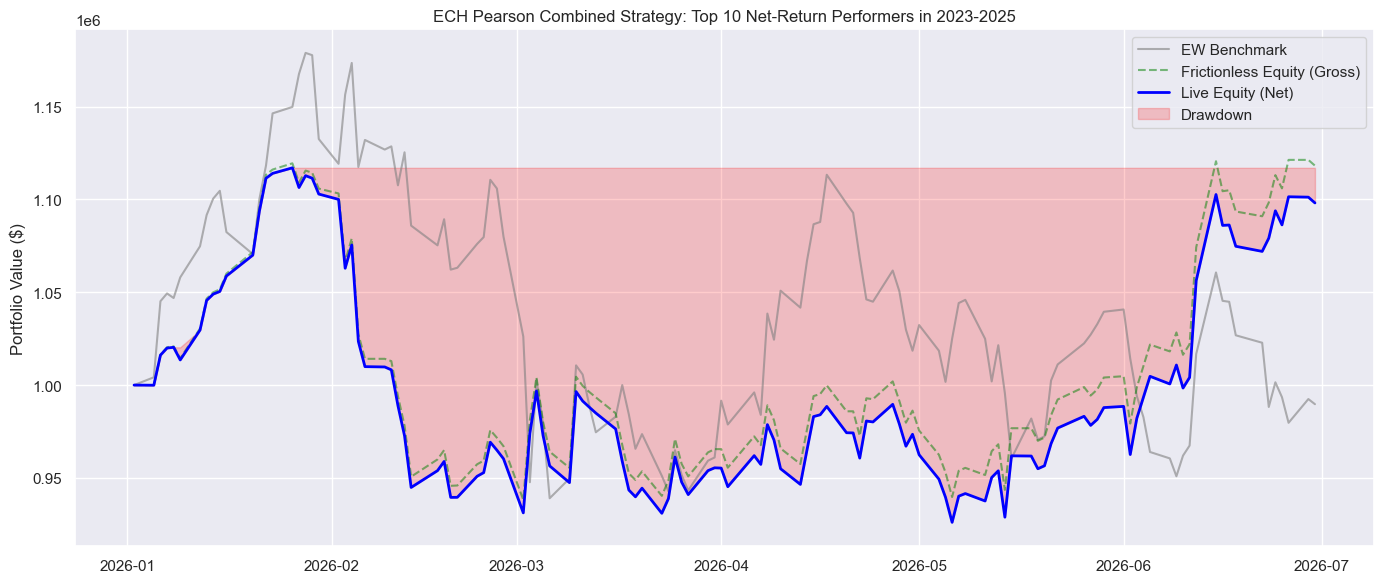

,grid_index,run_id,n_features,signal_threshold,position_size
0,115,ECH_features-15_sig-0p003,15,0.003,0.1
1,123,ECH_features-16_sig-0p003,16,0.003,0.1
2,131,ECH_features-17_sig-0p003,17,0.003,0.1
3,16,ECH_features-3_sig-0,3,0.000,0.1
4,107,ECH_features-14_sig-0p003,14,0.003,0.1
5,90,ECH_features-12_sig-0p002,12,0.002,0.1
6,98,ECH_features-13_sig-0p002,13,0.002,0.1
7,116,ECH_features-15_sig-0p004,15,0.004,0.1
8,8,ECH_features-2_sig-0,2,0.000,0.1
9,99,ECH_features-13_sig-0p003,13,0.003,0.1


,ECH_features-15_sig-0p003,ECH_features-16_sig-0p003,ECH_features-17_sig-0p003,ECH_features-3_sig-0,ECH_features-14_sig-0p003,ECH_features-12_sig-0p002,ECH_features-13_sig-0p002,ECH_features-15_sig-0p004,ECH_features-2_sig-0,ECH_features-13_sig-0p003
Timestamp,,,,,,,,,,
2026-01-02,0.1,0.1,0.1,-0.1,-0.1,0.1,0.1,0.1,-0.1,0.1
2026-01-05,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-06,-0.1,-0.1,-0.1,0.1,-0.1,0.1,0.1,-0.1,0.1,-0.1
2026-01-07,-0.1,-0.1,-0.1,-0.1,-0.1,0.1,0.1,-0.1,-0.1,-0.1
2026-01-08,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


,ECH
Timestamp,
2026-01-02,0.4
2026-01-05,1.0
2026-01-06,-0.2
2026-01-07,-0.6
2026-01-08,1.0


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,1.344502e-02,1.113079e+06,48.878588,19221.550144,1.093858e+06,0.013639,1.001498
2026-06-25,-6.408004e-03,1.105947e+06,438.216569,19659.766713,1.086287e+06,-0.006921,0.993476
2026-06-26,1.387836e-02,1.121295e+06,206.733622,19866.500335,1.101429e+06,0.013939,0.979689
2026-06-29,3.622133e-19,1.121295e+06,211.258976,20077.759311,1.101218e+06,-0.000192,0.992474
2026-06-30,-2.778495e-03,1.118180e+06,0.000000,20077.759311,1.098102e+06,-0.002829,0.989716


In [21]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows_2023_2025 = (
    metrics_df_2023_2025
    .sort_values("net_return_pct", ascending=False)
    .head(10)
)

combined_specs_2023_2025_top10 = []
for grid_index, row in top_10_return_rows_2023_2025.iterrows():
    combined_specs_2023_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2023_2025_top10 = {}
combined_weights_parts_2023_2025_top10 = []

for spec in combined_specs_2023_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date="2026-01-01",
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2023_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2023_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2023_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2023_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2023_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2023_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2023_2025_top10[run_id] = artifacts
    combined_weights_parts_2023_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2023_2025_top10 = pd.concat(
    combined_weights_parts_2023_2025_top10,
    axis=1,
).fillna(0)

combined_weights_2023_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2023_2025_top10.sum(axis=1)},
    index=combined_component_weights_2023_2025_top10.index,
)

combined_prices_2023_2025_top10 = (
    next(iter(combined_artifacts_2023_2025_top10.values()))["prices"]
    .loc[combined_weights_2023_2025_top10.index]
)

combined_engine_2023_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2023_2025_top10,
    signals=combined_weights_2023_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2023_2025_top10 = combined_engine_2023_2025_top10.run()
combined_engine_2023_2025_top10.tearsheet(
    "ECH Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025"
)

combined_strategy_2023_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2023_2025_top10,
    "component_artifacts": combined_artifacts_2023_2025_top10,
    "component_weights": combined_component_weights_2023_2025_top10,
    "weights": combined_weights_2023_2025_top10,
    "prices": combined_prices_2023_2025_top10,
    "engine": combined_engine_2023_2025_top10,
    "stats": combined_stats_2023_2025_top10,
}

display(pd.DataFrame(combined_specs_2023_2025_top10))
display(combined_component_weights_2023_2025_top10.head())
display(combined_weights_2023_2025_top10.head())
display(combined_stats_2023_2025_top10.tail())

## Single Candidate Rerun With Tearsheet



Use this section after the grid to rerun any candidate with the full tearsheet output. The grid suppresses tearsheets so the parallel run stays readable.

Rerunning ECH_features-17_sig-0p0075 with tearsheet output
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.20s |  elapsed: 1m 41.7s
✅ Prediction complete. Took 1m 42.1s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     13.67%
   Net Strategy Return:     13.28%  (EW Benchmark: 65.17%)
   Max Drawdown:            -1.65%
   Win Rate (Gross Bars):   5.6%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  2.4%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  92.0%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      2.25    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        4.74    (EW Benchmark: 2.67)
   Total Fees Paid:         $3,923.91
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


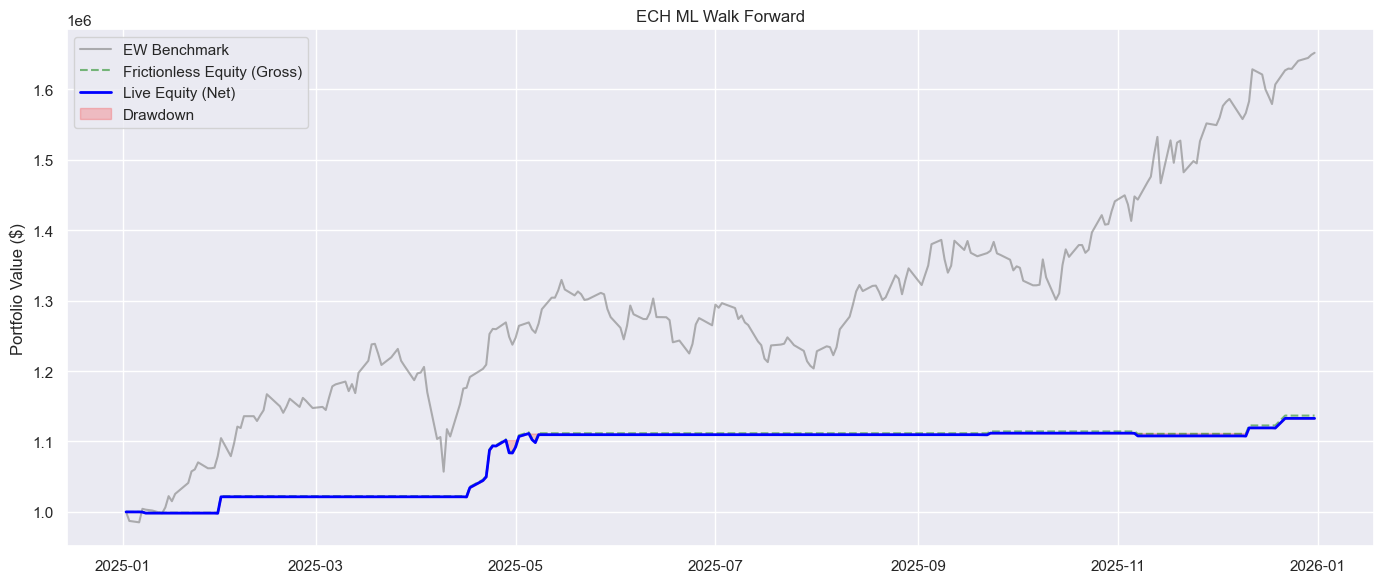

run_id,ECH_features-17_sig-0p0075
grid_index,134
symbol,ECH
n_features,17
signal_threshold,0.0075
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,13.673266
net_return_pct,13.280875
benchmark_return_pct,65.173061


In [15]:
target_run_id = metrics_df.sort_values("net_sharpe", ascending=False).iloc[0]["run_id"]
target = metrics_df.set_index("run_id").loc[target_run_id]
target_grid_index = int(metrics_df[metrics_df["run_id"] == target_run_id].index[0])

print(f"Rerunning {target_run_id} with tearsheet output")

single_artifacts = run_single_case_features_capture(
    symbol=SYMBOL,
    asset_class=ASSET_CLASS,
    start_date=COMMON_PARAMS_2025["start_date"],
    end_date=COMMON_PARAMS_2025["end_date"],
    signal_threshold=float(target["signal_threshold"]),
    n_features=int(target["n_features"]),
    training_years=COMMON_PARAMS_2025["training_years"],
    sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
    feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
    feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
    position_size=COMMON_PARAMS_2025["position_size"],
    initial_capital=INITIAL_CAPITAL,
    max_iter=COMMON_PARAMS_2025["max_iter"],
    execution_delay=EXECUTION_DELAY,
    verbose=COMMON_PARAMS_2025["verbose"],
    show_progress=True,
    show_tearsheet=True,
)

single_metrics = summarize_performance(
    target_run_id,
    target_grid_index,
    single_artifacts["params"],
    single_artifacts["stats"],
    single_artifacts["weights"],
    single_artifacts["strategy"],
)

display(pd.DataFrame([single_metrics]).set_index("run_id").T)

Rerunning ECH_features-17_sig-0p0075 with tearsheet output
🧠 Predicting 2025-12-31 |  1508/1508 |  last: 0.45s |  elapsed: 15m 51.9s5s
✅ Prediction complete. Took 15m 52.6s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     41.29%
   Net Strategy Return:     37.50%  (EW Benchmark: 51.31%)
   Max Drawdown:            -8.83%
   Win Rate (Gross Bars):   3.3%   (EW Benchmark: 50.6%)
   Loss Rate (Gross Bars):  1.9%   (EW Benchmark: 48.1%)
   Zero Rate (Gross Bars):  94.8%    (EW Benchmark: 1.3%)
   Sharpe Ratio (Net):      0.85    (EW Benchmark: 0.38)
   Sortino/√2 (Net):        1.01    (EW Benchmark: 0.39)
   Total Fees Paid:         $37,897.64
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


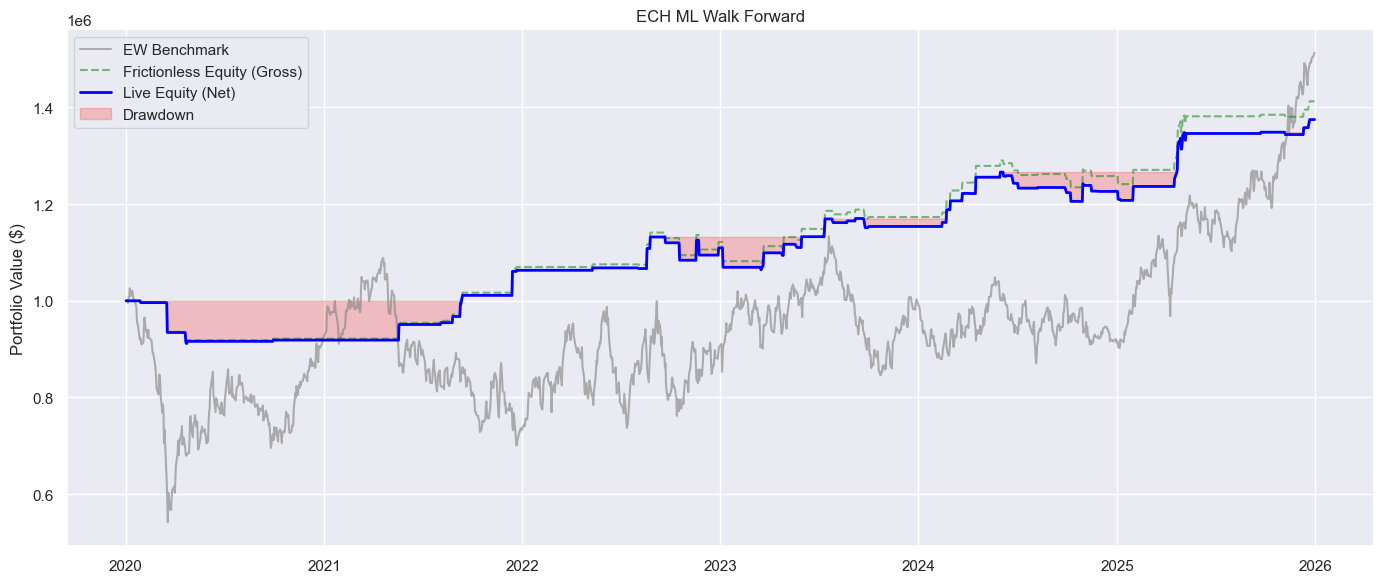

run_id,ECH_features-17_sig-0p0075
grid_index,134
symbol,ECH
n_features,17
signal_threshold,0.0075
training_years,10
start_date,2020-01-01
end_date,2026-01-01
gross_return_pct,41.289116
net_return_pct,37.499353
benchmark_return_pct,51.310527


In [17]:
target_run_id = metrics_df.sort_values("net_sharpe", ascending=False).iloc[0]["run_id"]
target = metrics_df.set_index("run_id").loc[target_run_id]
target_grid_index = int(metrics_df[metrics_df["run_id"] == target_run_id].index[0])

print(f"Rerunning {target_run_id} with tearsheet output")

single_artifacts = run_single_case_features_capture(
    symbol=SYMBOL,
    asset_class=ASSET_CLASS,
    # start_date=COMMON_PARAMS_2025["start_date"],
    start_date="2020-01-01",
    # end_date=COMMON_PARAMS_2025["end_date"],
    end_date="2026-01-01",
    signal_threshold=float(target["signal_threshold"]),
    n_features=int(target["n_features"]),
    training_years=COMMON_PARAMS_2025["training_years"],
    sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
    feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
    feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
    position_size=COMMON_PARAMS_2025["position_size"],
    initial_capital=INITIAL_CAPITAL,
    max_iter=COMMON_PARAMS_2025["max_iter"],
    execution_delay=EXECUTION_DELAY,
    verbose=COMMON_PARAMS_2025["verbose"],
    show_progress=True,
    show_tearsheet=True,
)

single_metrics = summarize_performance(
    target_run_id,
    target_grid_index,
    single_artifacts["params"],
    single_artifacts["stats"],
    single_artifacts["weights"],
    single_artifacts["strategy"],
)

display(pd.DataFrame([single_metrics]).set_index("run_id").T)